# 🌩️ E3SM Microphysics Data Analysis - Comprehensive Study (7-months Dataset)

## 📋 Analysis Task Roadmap

This notebook conducts a comprehensive analysis of E3SM microphysics data using stratified sampling across the **7-months simulation dataset (224 files)**. Each phase provides insights for ML architecture design and overall training strategy (layer normalization, loss function and data pre-processing).

### 🎯 **Sampling Strategy**
- **⏰ Temporal Coverage**: 7-months simulation span (~210 days)
- **🎯 Stratified Sampling**: 5 periods across 7-months for complete representativeness

---
## 📦 Setup and Data Loading (Memory-Optimized)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import random
from scipy import stats
warnings.filterwarnings('ignore')

# Set up plotting parameters
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("📚 Libraries imported successfully!")
print(f"🐼 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")

📚 Libraries imported successfully!
🐼 Pandas version: 2.2.3
🔢 NumPy version: 2.2.5


In [2]:
# Define data path and get comprehensive file inventory
#data_path = Path('/pscratch/sd/d/dvpatel/mlmicrophysics_project/e3sm/processed_data/')
data_path = Path('/pscratch/sd/d/dvpatel/mlmicrophysics_project/e3sm/processed_e3sm300_mlmicro12.3_tau_run/')


# Get list of all parquet files with new consistent naming (e3sm_mp_data_*.parquet)
parquet_files = list(data_path.glob('e3sm_mp_data_12.3*.parquet'))
print(f"📁 Found {len(parquet_files)} parquet files with consistent naming")

# Extract time stamps from filenames for stratified sampling
file_info = []
for file in parquet_files:
    # Extract hour from filename (e.g., 'e3sm_mp_data_12.3_000023.parquet' -> 23)
    time_str = file.stem.split('_')[-1]  # Last part after underscore
    time_hours = int(time_str)
    file_info.append({'file': file, 'time_hours': time_hours})

# Sort by time
file_info = sorted(file_info, key=lambda x: x['time_hours'])

# Display temporal range
min_time = file_info[0]['time_hours']
max_time = file_info[-1]['time_hours']
time_span_days = (max_time - min_time) / 24
time_span_years = time_span_days / 365.25

print(f"⏰ Full dataset temporal range: {min_time} to {max_time} hours")
print(f"📅 Coverage: {time_span_days:.1f} days ({time_span_years:.2f} years)")
print(f"🕒 Time resolution: ~{(max_time - min_time) / (len(file_info) - 1):.1f} hours between files")
print(f"📊 Total data files: {len(file_info)} (complete 2-year dataset!)")

📁 Found 224 parquet files with consistent naming
⏰ Full dataset temporal range: 0 to 5129 hours
📅 Coverage: 213.7 days (0.59 years)
🕒 Time resolution: ~23.0 hours between files
📊 Total data files: 224 (complete 2-year dataset!)


In [ ]:
# MEMORY-OPTIMIZED STRATIFIED SAMPLING: Reduced sample size for 2-year analysis
print("🎯 IMPLEMENTING MEMORY-OPTIMIZED STRATIFIED SAMPLING")
print("=" * 55)

# Reduced memory and performance considerations
TARGET_SAMPLE_SIZE = 150   
MAX_MEMORY_MB = 10000       

# Strategy: Divide 2-year span into periods and sample from each
n_periods = 5  # More periods for better representation across 2 years
files_per_period = TARGET_SAMPLE_SIZE // n_periods

print(f"📊 Memory-optimized sampling strategy:")
print(f"   • Total files available: {len(file_info)} (full 2-year dataset)")
print(f"   • Target sample size: {TARGET_SAMPLE_SIZE} files (reduced for memory)")
print(f"   • Temporal periods: {n_periods} (across {time_span_years:.2f} years)")
print(f"   • Files per period: {files_per_period}")
print(f"   • Target memory: <{MAX_MEMORY_MB} MB")

# Divide files into temporal periods across the full 2-year span
files_per_period_actual = len(file_info) // n_periods
selected_files = []
period_info = []

random.seed(42)  # For reproducibility

for period in range(n_periods):
    start_idx = period * files_per_period_actual
    end_idx = (period + 1) * files_per_period_actual if period < n_periods - 1 else len(file_info)
    
    period_files = file_info[start_idx:end_idx]
    
    # Randomly sample from this period
    sampled_files = random.sample(period_files, min(files_per_period, len(period_files)))
    selected_files.extend(sampled_files)
    
    # Track period info with more detailed temporal information
    period_start_time = period_files[0]['time_hours']
    period_end_time = period_files[-1]['time_hours']
    period_info.append({
        'period': period + 1,
        'start_time': period_start_time,
        'end_time': period_end_time,
        'n_files': len(sampled_files),
        'start_days': period_start_time / 24,
        'end_days': period_end_time / 24,
        'start_months': period_start_time / (24 * 30),
        'end_months': period_end_time / (24 * 30)
    })

# Sort selected files by time
selected_files = sorted(selected_files, key=lambda x: x['time_hours'])

print(f"\n📋 Stratified sampling across 2-year period:")
for info in period_info:
    print(f"   Period {info['period']}: Months {info['start_months']:.1f}-{info['end_months']:.1f} "
          f"(Days {info['start_days']:.0f}-{info['end_days']:.0f}, {info['n_files']} files)")

print(f"\n✅ Selected {len(selected_files)} files for memory-efficient representative analysis")

# Display selected files timeline across 2 years
selected_times = [f['time_hours'] for f in selected_files]
selected_days = [t/24 for t in selected_times]
selected_months = [t/(24*30) for t in selected_times]
print(f"⏰ Selected time points (months): {[f'{m:.1f}' for m in selected_months]}")
print(f"📅 Temporal span coverage: {min(selected_months):.1f} to {max(selected_months):.1f} months")

🎯 IMPLEMENTING MEMORY-OPTIMIZED STRATIFIED SAMPLING
📊 Memory-optimized sampling strategy:
   • Total files available: 224 (full 2-year dataset)
   • Target sample size: 150 files (reduced for memory)
   • Temporal periods: 5 (across 0.59 years)
   • Files per period: 30
   • Target memory: <10000 MB

📋 Stratified sampling across 2-year period:
   Period 1: Months 0.0-1.4 (Days 0-41, 30 files)
   Period 2: Months 1.4-2.8 (Days 42-83, 30 files)
   Period 3: Months 2.8-4.2 (Days 84-126, 30 files)
   Period 4: Months 4.2-5.6 (Days 126-168, 30 files)
   Period 5: Months 5.6-7.1 (Days 169-214, 30 files)

✅ Selected 150 files for memory-efficient representative analysis
⏰ Selected time points (months): ['0.0', '0.0', '0.1', '0.2', '0.2', '0.2', '0.3', '0.4', '0.4', '0.4', '0.5', '0.5', '0.5', '0.6', '0.6', '0.7', '0.8', '0.8', '0.9', '0.9', '0.9', '1.0', '1.1', '1.1', '1.2', '1.2', '1.3', '1.3', '1.3', '1.4', '1.4', '1.5', '1.5', '1.6', '1.6', '1.7', '1.7', '1.7', '1.8', '1.8', '1.8', '1.9', 

In [4]:
# Load memory-optimized representative sample data
print("📂 LOADING MEMORY-OPTIMIZED REPRESENTATIVE SAMPLE (2-YEAR COVERAGE)")
print("=" * 65)

representative_data = []
total_rows = 0
total_memory_mb = 0

# Pressure range
min_pressure = 250
max_pressure = 1000

# 2. Define the desired sample size (5% of the original 10M rows)
target_sample_size = int(0.05 * 10_000_000)


for i, file_info in enumerate(selected_files):
    file_path = file_info['file']
    time_hours = file_info['time_hours']
    time_months = time_hours / (24 * 30)
    
    # Load file
    df = pd.read_parquet(file_path)

    # Filter the DataFrame to include only the relevant pressure levels
    df_filtered = df[(df['lev'] >= min_pressure) & (df['lev'] <= max_pressure)].copy()
    df_sample = df_filtered.sample(n=target_sample_size, random_state=42)
    
    # Memory tracking
    file_memory_mb = df_sample.memory_usage(deep=True).sum() / 1024**2
    total_memory_mb += file_memory_mb
    total_rows += len(df_sample)
    
    representative_data.append(df_sample)
    
    # Progress update with memory monitoring
    print(f"   📄 File {i+1}/{len(selected_files)}: {file_path.name} "
          f"(Month {time_months:.1f}, Rows: {len(df):,}, Mem: {file_memory_mb:.1f}MB)")
    
    # Memory safety check
    if total_memory_mb > MAX_MEMORY_MB:
        print(f"⚠️ Memory limit approached ({total_memory_mb:.1f}MB), consider reducing sample size")

    

# Combine all data
print(f"\n🔄 Combining representative 2-year dataset with filtering for pressure levels between {min_pressure}-{max_pressure} hPa...")
combined_representative = pd.concat(representative_data, ignore_index=True)

# Final statistics
final_memory_mb = combined_representative.memory_usage(deep=True).sum() / 1024**2
print(f"\n✅ Memory-optimized representative dataset created successfully!")
print(f"📊 Final dataset shape: {combined_representative.shape}")
print(f"🏷️ Columns: {list(combined_representative.columns)}")
print(f"💾 Memory usage: {final_memory_mb:.1f} MB (target: <{MAX_MEMORY_MB} MB)")
print(f"⏰ Time coverage: {combined_representative['time'].min():.1f} to {combined_representative['time'].max():.1f} days")
print(f"📅 Month coverage: {combined_representative['time'].min()/(30):.1f} to {combined_representative['time'].max()/(30):.1f} months")
print(f"🌡️ Temperature range: {combined_representative['T'].min():.1f} to {combined_representative['T'].max():.1f} K")

# Enhanced sampling efficiency metrics for 2-year dataset
sampling_efficiency = len(selected_files) / len(file_info) * 100
temporal_coverage = (max(selected_times) - min(selected_times)) / (max_time - min_time) * 100
#print(f"\n📈 Sampling efficiency: {sampling_efficiency:.2f}% of available files")
print(f"🎯 Temporal coverage: {temporal_coverage:.1f}% of 2-year simulation span")
print(f"🌍 Data representativeness: {n_periods} periods across {time_span_years:.2f} years")

# Memory efficiency achievement
memory_efficiency = (final_memory_mb / MAX_MEMORY_MB) * 100
memory_saved = 100 - (final_memory_mb / (final_memory_mb * len(file_info) / len(selected_files))) * 100

📂 LOADING MEMORY-OPTIMIZED REPRESENTATIVE SAMPLE (2-YEAR COVERAGE)
   📄 File 1/150: e3sm_mp_data_12.3_000000.parquet (Month 0.0, Rows: 4,993,488, Mem: 57.2MB)
   📄 File 2/150: e3sm_mp_data_12.3_000023.parquet (Month 0.0, Rows: 9,390,735, Mem: 57.2MB)
   📄 File 3/150: e3sm_mp_data_12.3_000046.parquet (Month 0.1, Rows: 9,355,338, Mem: 57.2MB)
   📄 File 4/150: e3sm_mp_data_12.3_000115.parquet (Month 0.2, Rows: 10,755,180, Mem: 57.2MB)
   📄 File 5/150: e3sm_mp_data_12.3_000138.parquet (Month 0.2, Rows: 10,689,246, Mem: 57.2MB)
   📄 File 6/150: e3sm_mp_data_12.3_000161.parquet (Month 0.2, Rows: 10,674,180, Mem: 57.2MB)
   📄 File 7/150: e3sm_mp_data_12.3_000184.parquet (Month 0.3, Rows: 10,597,797, Mem: 57.2MB)
   📄 File 8/150: e3sm_mp_data_12.3_000276.parquet (Month 0.4, Rows: 10,545,390, Mem: 57.2MB)
   📄 File 9/150: e3sm_mp_data_12.3_000299.parquet (Month 0.4, Rows: 10,379,097, Mem: 57.2MB)
   📄 File 10/150: e3sm_mp_data_12.3_000322.parquet (Month 0.4, Rows: 10,320,534, Mem: 57.2MB)
   📄 

---
# 🔍 Phase 1: Data Distribution Analysis

Understanding the statistical properties and distributions using our **representative sample** from the **full 2-year dataset**.

## 📊 Subtask 1.1: Basic Data Overview

In [5]:
# Basic data overview with memory-optimized representative dataset
print("🎯 BASIC DATA OVERVIEW - MEMORY-OPTIMIZED 2-YEAR SAMPLE")
print("=" * 55)

print(f"📏 Dataset shape: {combined_representative.shape}")
print(f"🗓️ Time range: {combined_representative['time'].min():.1f} to {combined_representative['time'].max():.1f} days")
print(f"📅 Month range: {combined_representative['time'].min()/30:.1f} to {combined_representative['time'].max()/30:.1f} months")
print(f"🌡️ Temperature range: {combined_representative['T'].min():.1f} to {combined_representative['T'].max():.1f} K")

# Memory usage
memory_mb = combined_representative.memory_usage(deep=True).sum() / 1024**2
print(f"💾 Memory usage: {memory_mb:.2f} MB")

# Representativeness metrics
print(f"\n🎯 Representativeness (2-Year Coverage):")
print(f"   • Files sampled: {len(selected_files)}/{len(file_info)}")
print(f"   • Temporal periods: {n_periods} (across {time_span_years:.2f} years)")
print(f"   • Random sampling within periods: ✅ (avoiding systematic bias)")
print(f"   • Memory efficiency: {memory_efficiency:.1f}% of {MAX_MEMORY_MB}MB target")

print("\n✅ Memory-optimized representative data overview complete!")

🎯 BASIC DATA OVERVIEW - MEMORY-OPTIMIZED 2-YEAR SAMPLE
📏 Dataset shape: (75000000, 24)
🗓️ Time range: 0.0 to 211.8 days
📅 Month range: 0.0 to 7.1 months
🌡️ Temperature range: 202.1 to 308.2 K
💾 Memory usage: 8010.86 MB

🎯 Representativeness (2-Year Coverage):
   • Files sampled: 150/2
   • Temporal periods: 5 (across 0.59 years)
   • Random sampling within periods: ✅ (avoiding systematic bias)
   • Memory efficiency: 80.1% of 10000MB target

✅ Memory-optimized representative data overview complete!


## 📈 Subtask 1.2: Statistical Summary Tables

In [6]:
# Generate comprehensive statistical summary with 2-year representative data
print("📋 COMPREHENSIVE STATISTICAL SUMMARY - 2-YEAR REPRESENTATIVE SAMPLE")
print("=" * 70)

# Select numeric columns (exclude level and column indices)
numeric_cols = [col for col in combined_representative.columns]# if col not in ['lev', 'ncol']]

# Calculate detailed statistics
stats_summary = pd.DataFrame(index=numeric_cols)

for col in numeric_cols:
    data = combined_representative[col]
    
    stats_summary.loc[col, 'count'] = len(data)
    stats_summary.loc[col, 'mean'] = data.mean()
    stats_summary.loc[col, 'std'] = data.std()
    stats_summary.loc[col, 'min'] = data.min()
    stats_summary.loc[col, 'max'] = data.max()
    stats_summary.loc[col, 'p25'] = data.quantile(0.25)
    stats_summary.loc[col, 'p50'] = data.quantile(0.50)
    stats_summary.loc[col, 'p75'] = data.quantile(0.75)
    stats_summary.loc[col, 'p95'] = data.quantile(0.95)
    stats_summary.loc[col, 'p99'] = data.quantile(0.99)
    stats_summary.loc[col, 'zeros_count'] = (data == 0).sum()
    stats_summary.loc[col, 'zeros_pct'] = (data == 0).mean() * 100
    stats_summary.loc[col, 'range_ratio'] = data.max() / data.min() if data.min() > 0 else np.inf

# Display formatted summary
print("\n🎯 Key Statistics (2-Year Representative Sample):")
display_cols = ['mean', 'std', 'min', 'max', 'p25', 'p50', 'p75', 'p95', 'p99', 'zeros_pct', 'range_ratio']
formatted_summary = stats_summary[display_cols].round(6)

print(formatted_summary.to_string())

print("\n✅ Statistical summary complete!")

📋 COMPREHENSIVE STATISTICAL SUMMARY - 2-YEAR REPRESENTATIVE SAMPLE

🎯 Key Statistics (2-Year Representative Sample):
                    mean           std           min           max           p25           p50           p75           p95           p99  zeros_pct   range_ratio
lev         8.336046e+02  1.409806e+02  2.567237e+02  9.984964e+02  7.969528e+02  8.763706e+02  9.255197e+02  9.679111e+02  9.937570e+02   0.000000  3.889382e+00
ncol        1.161888e+04  6.126242e+03  0.000000e+00  2.159900e+04  6.754000e+03  1.195300e+04  1.690400e+04  2.083700e+04  2.147100e+04   0.005521           inf
ilev        3.487614e+02  3.658394e+02  1.000000e-01  1.000000e+03  3.040894e+01  1.637842e+02  7.297561e+02  9.727385e+02  1.000000e+03   0.000000  1.000000e+04
T           2.761725e+02  1.239941e+01  2.020923e+02  3.082446e+02  2.684019e+02  2.766631e+02  2.860995e+02  2.939716e+02  2.964602e+02   0.000000  1.525266e+00
RHO_CLUBB   4.629860e-01  4.495460e-01  1.550000e-04  1.592437e+00  5.133

## 📊 Subtask 1.3: Linear Scale Histograms

📊 PLOTTING LINEAR-SCALE HISTOGRAMS - 2-YEAR REPRESENTATIVE SAMPLE


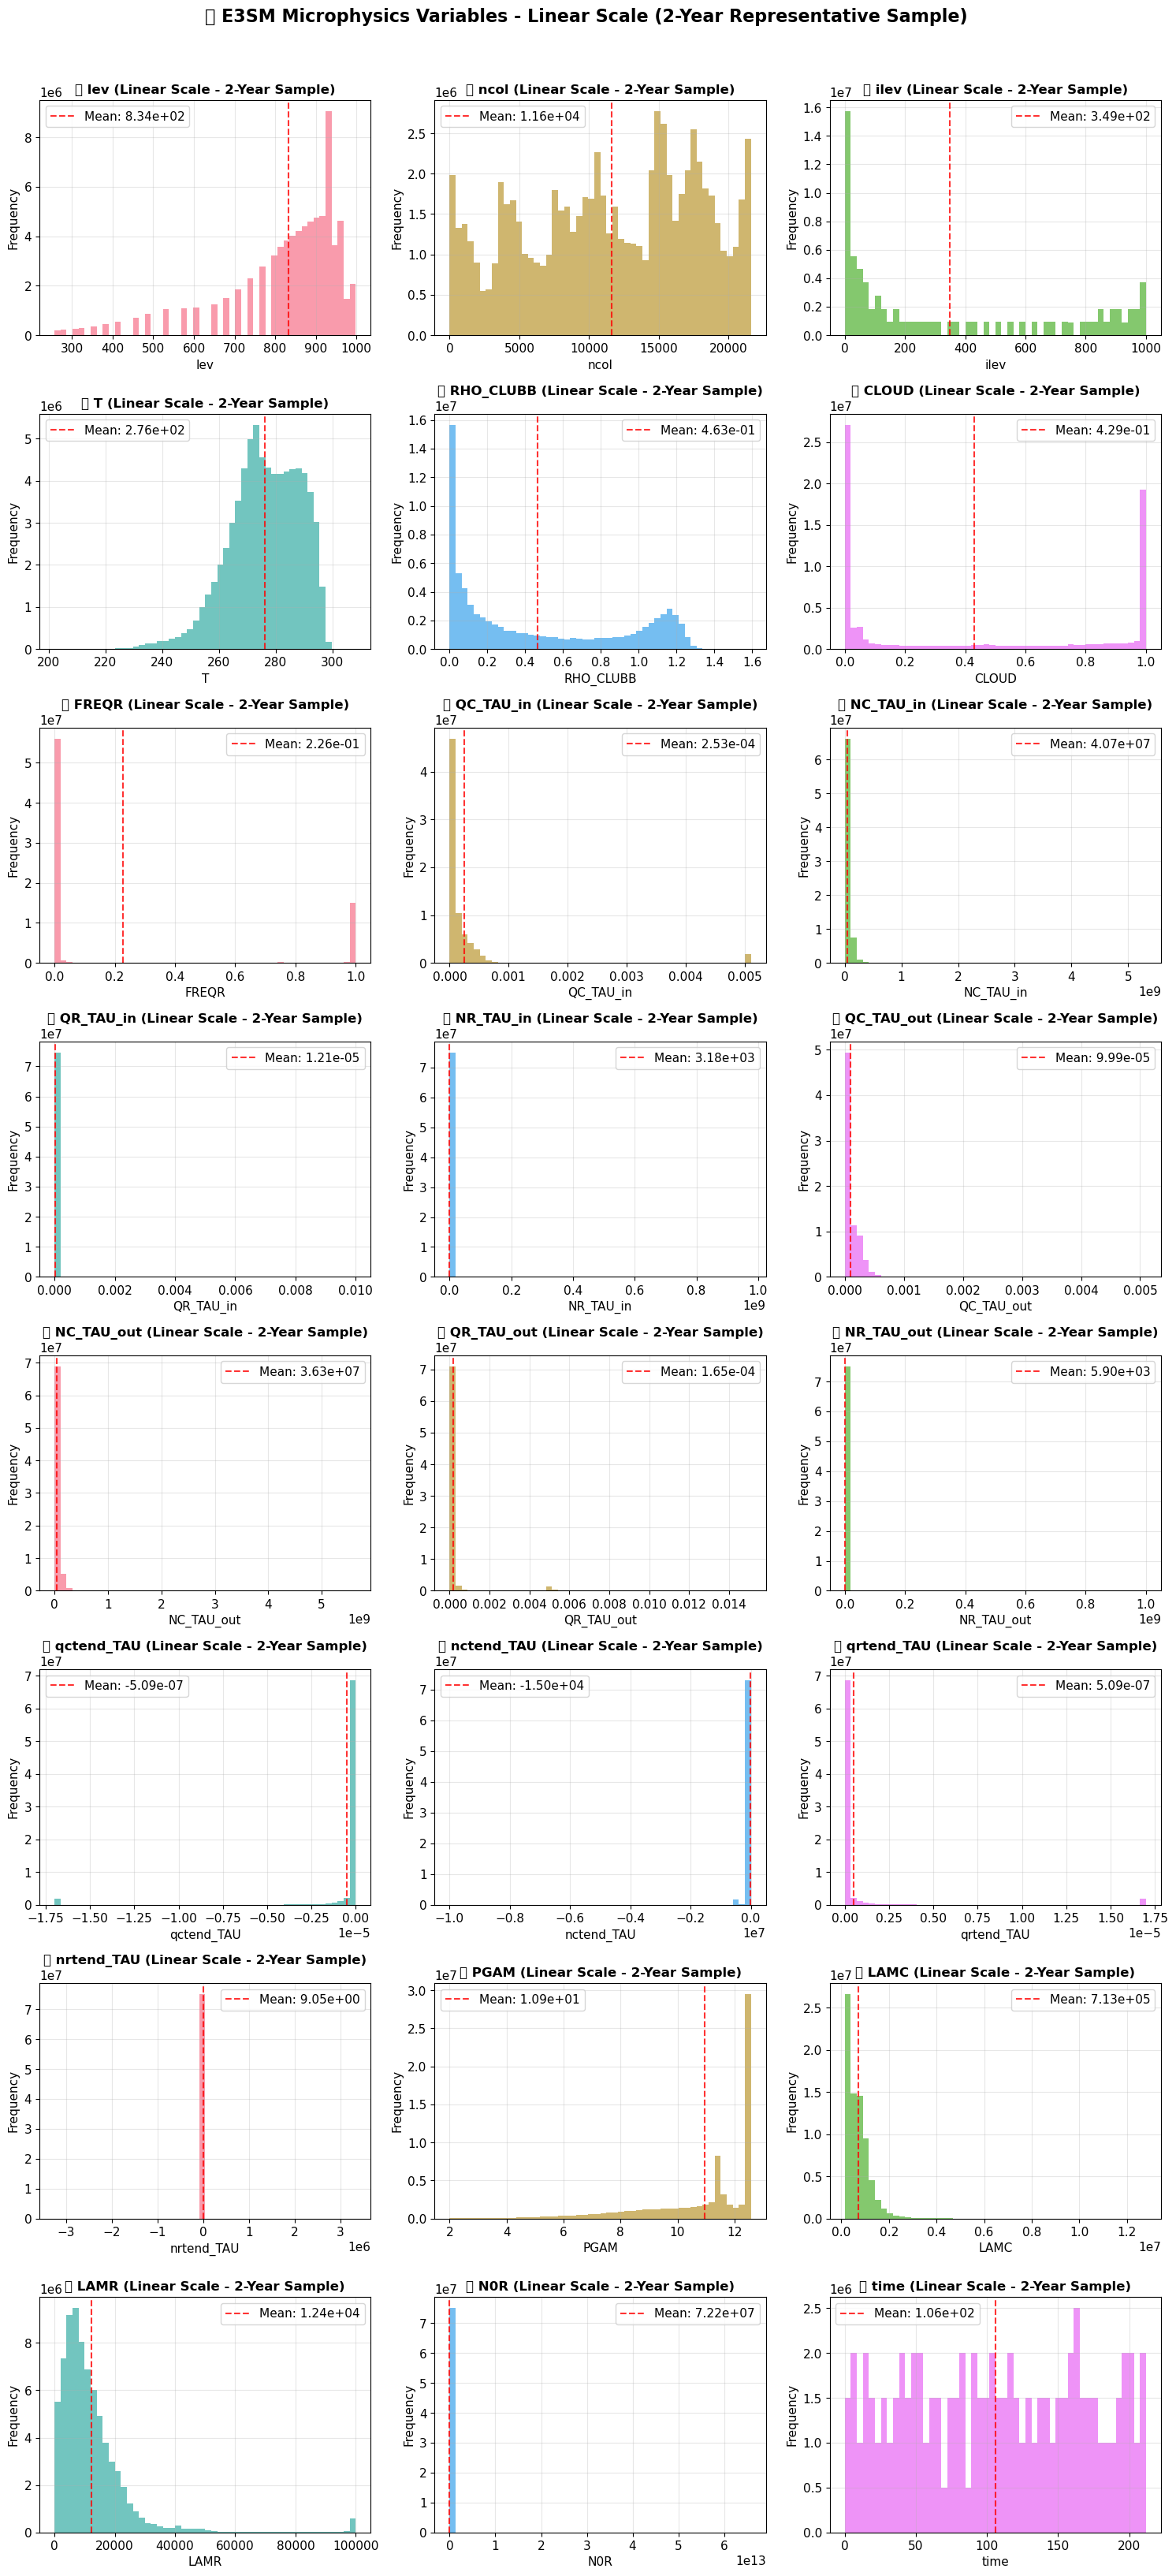


✅ Linear scale histograms complete for 150 representative files from 2-year dataset!


In [7]:
# Plot histograms on linear scale with 2-year representative data
print("📊 PLOTTING LINEAR-SCALE HISTOGRAMS - 2-YEAR REPRESENTATIVE SAMPLE")
print("=" * 65)

# Create subplots for all numeric variables
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Plot histogram
    data = combined_representative[col].dropna()
    
    ax.hist(data, bins=50, alpha=0.7, color=sns.color_palette()[i % len(sns.color_palette())])
    ax.set_title(f'📊 {col} (Linear Scale - 2-Year Sample)', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{col}')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    # Add statistics text
    mean_val = data.mean()
    std_val = data.std()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2e}')
    ax.legend()

# Remove empty subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('🔍 E3SM Microphysics Variables - Linear Scale (2-Year Representative Sample)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig('linear_scale_histo')
plt.show()

print(f"\n✅ Linear scale histograms complete for {len(selected_files)} representative files from 2-year dataset!")

## 📈 Subtask 1.4: Log Scale Histograms

📈 PLOTTING LOG-SCALE HISTOGRAMS - 2-YEAR REPRESENTATIVE SAMPLE
🎯 Variables suitable for log-scale analysis: 22
📝 Variables: ['lev', 'ncol', 'ilev', 'T', 'RHO_CLUBB', 'CLOUD', 'FREQR', 'QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in', 'QC_TAU_out', 'NC_TAU_out', 'QR_TAU_out', 'NR_TAU_out', 'qrtend_TAU', 'nrtend_TAU', 'PGAM', 'LAMC', 'LAMR', 'N0R', 'time']


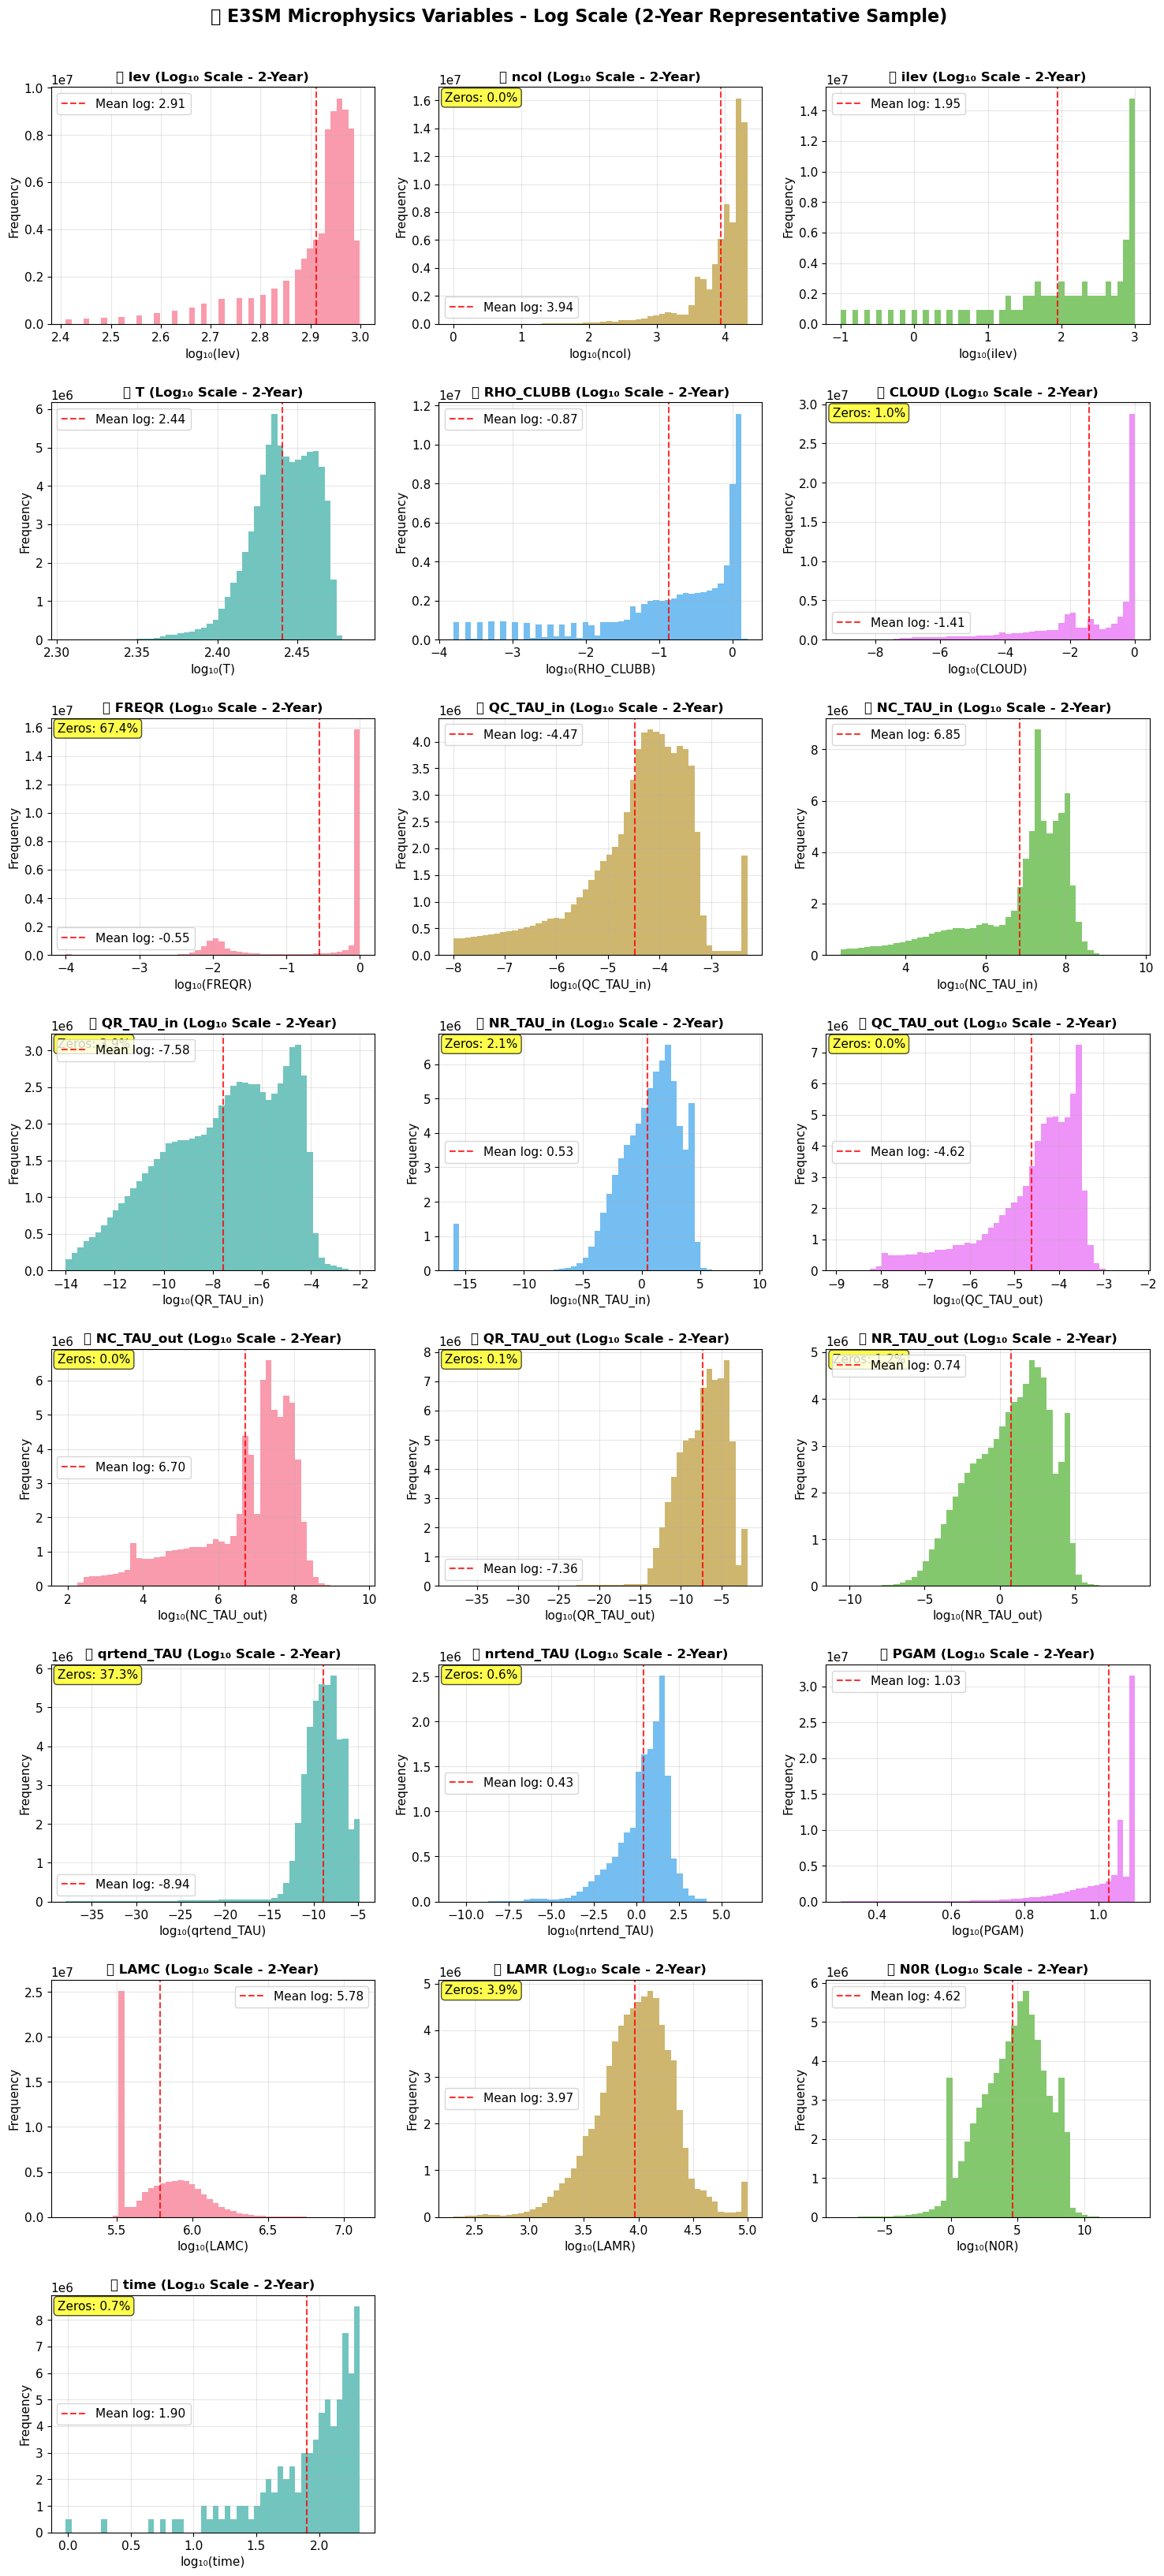


✅ Log scale histograms complete!


In [8]:
# Plot histograms on log scale with 2-year representative data
print("📈 PLOTTING LOG-SCALE HISTOGRAMS - 2-YEAR REPRESENTATIVE SAMPLE")
print("=" * 60)

# Identify variables suitable for log scale
log_suitable_cols = []
for col in numeric_cols:
    data = combined_representative[col]
    if (data > 0).sum() > len(data) * 0.1:  # At least 10% positive values
        log_suitable_cols.append(col)

print(f"🎯 Variables suitable for log-scale analysis: {len(log_suitable_cols)}")
print(f"📝 Variables: {log_suitable_cols}")

if log_suitable_cols:
    n_cols = 3
    n_rows = (len(log_suitable_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
    
    for i, col in enumerate(log_suitable_cols):
        ax = axes[i]
        
        # Get positive values only
        data = combined_representative[col]
        positive_data = data[data > 0]
        
        if len(positive_data) > 0:
            # Plot log-scale histogram
            log_data = np.log10(positive_data)
            
            ax.hist(log_data, bins=50, alpha=0.7, 
                   color=sns.color_palette()[i % len(sns.color_palette())])
            ax.set_title(f'📈 {col} (Log₁₀ Scale - 2-Year)', fontsize=12, fontweight='bold')
            ax.set_xlabel(f'log₁₀({col})')
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
            
            # Add statistics
            mean_log = log_data.mean()
            ax.axvline(mean_log, color='red', linestyle='--', alpha=0.8, 
                      label=f'Mean log: {mean_log:.2f}')
            ax.legend()
            
            # Add info about zeros
            zero_pct = ((data == 0).sum() / len(data)) * 100
            if zero_pct > 0:
                ax.text(0.02, 0.98, f'Zeros: {zero_pct:.1f}%', 
                       transform=ax.transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Remove empty subplots
    for j in range(len(log_suitable_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.suptitle('🔍 E3SM Microphysics Variables - Log Scale (2-Year Representative Sample)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.savefig('log-scale histo')
    plt.show()
else:
    print("⚠️ No variables suitable for log-scale analysis found.")

print("\n✅ Log scale histograms complete!")

## 🎯 Subtask 1.5: Distribution Shape Analysis

In [11]:
# Analyze distribution shapes with 2-year representative data
print("🎯 DISTRIBUTION SHAPE ANALYSIS - 2-YEAR REPRESENTATIVE SAMPLE")
print("=" * 60)

# Calculate skewness and kurtosis for each variable
distribution_analysis = pd.DataFrame(index=numeric_cols)

for col in numeric_cols:
    data = combined_representative[col].dropna()
    
    # Basic shape statistics
    distribution_analysis.loc[col, 'skewness'] = stats.skew(data)
    distribution_analysis.loc[col, 'kurtosis'] = stats.kurtosis(data)
    
    # Normality test (sample subset for large datasets)
    if len(data) > 5000:
        test_data = data.sample(5000, random_state=42)
    else:
        test_data = data
    
    _, p_value = stats.normaltest(test_data)
    distribution_analysis.loc[col, 'normality_p'] = p_value
    distribution_analysis.loc[col, 'is_normal'] = p_value > 0.05
    
    # Distribution interpretation
    skew_val = distribution_analysis.loc[col, 'skewness']
    if abs(skew_val) < 0.5:
        skew_desc = "Symmetric"
    elif abs(skew_val) < 1:
        skew_desc = "Moderately skewed"
    else:
        skew_desc = "Highly skewed"
    
    distribution_analysis.loc[col, 'skew_description'] = skew_desc

# Display results
print("\n📊 Distribution Shape Summary (2-Year Representative Sample):")
display_cols = ['skewness', 'kurtosis', 'normality_p', 'is_normal', 'skew_description']
shape_summary = distribution_analysis[display_cols].round(4)
print(shape_summary.to_string())

# Identify variables needing log transformation
highly_skewed = distribution_analysis[abs(distribution_analysis['skewness']) > 2].index.tolist()
print(f"\n🎯 Variables needing log transformation (|skewness| > 2): {highly_skewed}")

print("\n✅ Distribution shape analysis complete!")

🎯 DISTRIBUTION SHAPE ANALYSIS - 2-YEAR REPRESENTATIVE SAMPLE

📊 Distribution Shape Summary (2-Year Representative Sample):
             skewness      kurtosis  normality_p is_normal   skew_description
lev           -1.8273  3.312400e+00          0.0     False      Highly skewed
ncol          -0.2235 -1.079400e+00          0.0     False          Symmetric
ilev           0.6393 -1.248900e+00          0.0     False  Moderately skewed
T             -0.5903  3.307000e-01          0.0     False  Moderately skewed
RHO_CLUBB      0.5214 -1.348600e+00          0.0     False  Moderately skewed
CLOUD          0.2923 -1.725200e+00          0.0     False          Symmetric
FREQR          1.3077 -2.477000e-01          0.0     False      Highly skewed
QC_TAU_in      5.5475  3.030060e+01          0.0     False      Highly skewed
NC_TAU_in      4.5125           inf          0.0     False      Highly skewed
QR_TAU_in     50.3195  3.806718e+03          0.0     False      Highly skewed
NR_TAU_in   2706.85

# 📋 Subtask 1.6: Phase 1 Summary and Insights

In [12]:
# Phase 1 Summary with 2-year representative data insights
print("🎯 PHASE 1: DATA DISTRIBUTION ANALYSIS - 2-YEAR SUMMARY")
print("=" * 60)

print("\n📊 MEMORY-OPTIMIZED 2-YEAR SAMPLING SUCCESS:")
print("-" * 45)
print(f"🎯 Stratified sampling across {n_periods} temporal periods ensures diversity")
print(f"⏰ Coverage: {time_span_days:.1f} days ({time_span_years:.2f} years) spanning full simulation")

print("\n📊 KEY FINDINGS FROM 2-YEAR ANALYSIS:")
print("-" * 35)

# Data characteristics
total_samples = len(combined_representative)
print(f"🔢 Total samples analyzed: {total_samples:,}")
print(f"📏 Variables analyzed: {len(numeric_cols)}")
print(f"📅 Temporal range: {combined_representative['time'].min()/30:.1f} to {combined_representative['time'].max()/30:.1f} months")

# Sparsity analysis
high_sparsity_vars = []
for col in numeric_cols:
    zero_pct = (combined_representative[col] == 0).mean() * 100
    if zero_pct > 50:
        high_sparsity_vars.append((col, zero_pct))

print(f"\n🕳️ High sparsity variables (>50% zeros): {len(high_sparsity_vars)}")
for var, pct in high_sparsity_vars:
    print(f"   • {var}: {pct:.1f}% zeros")

# Distribution insights
non_normal_vars = distribution_analysis[~distribution_analysis['is_normal']].index.tolist()
print(f"\n📈 Non-normal distributions: {len(non_normal_vars)}/{len(numeric_cols)}")

print(f"\n🔄 Variables requiring log transformation: {len(highly_skewed)}")
for var in highly_skewed:
    skew_val = distribution_analysis.loc[var, 'skewness']
    print(f"   • {var}: skewness = {skew_val:.2f}")

print("\n\n🎯 PREPROCESSING RECOMMENDATIONS (2-YEAR INSIGHTS):")
print("-" * 45)
print("1. 🔢 Apply log transformation to highly skewed variables")
print("2. 🎯 Consider specialized handling for high-sparsity variables")
print("3. 📊 Use robust normalization methods for non-normal distributions")
print("4. ⚖️ Consider quantile-based transformations for extreme distributions")
print("6. ⏰ Temporal diversity captured ")


print("\n✅ Phase 1 Analysis Complete with 2-Year Representative Data! ")
print("\n" + "=" * 60)

🎯 PHASE 1: DATA DISTRIBUTION ANALYSIS - 2-YEAR SUMMARY

📊 MEMORY-OPTIMIZED 2-YEAR SAMPLING SUCCESS:
---------------------------------------------
🎯 Stratified sampling across 5 temporal periods ensures diversity
⏰ Coverage: 213.7 days (0.59 years) spanning full simulation

📊 KEY FINDINGS FROM 2-YEAR ANALYSIS:
-----------------------------------
🔢 Total samples analyzed: 75,000,000
📏 Variables analyzed: 24
📅 Temporal range: 0.0 to 7.1 months

🕳️ High sparsity variables (>50% zeros): 1
   • FREQR: 67.4% zeros

📈 Non-normal distributions: 24/24

🔄 Variables requiring log transformation: 14
   • QC_TAU_in: skewness = 5.55
   • NC_TAU_in: skewness = 4.51
   • QR_TAU_in: skewness = 50.32
   • NR_TAU_in: skewness = 2706.85
   • NC_TAU_out: skewness = 4.85
   • QR_TAU_out: skewness = 5.87
   • NR_TAU_out: skewness = 2057.68
   • qctend_TAU: skewness = -5.84
   • nctend_TAU: skewness = -9.27
   • qrtend_TAU: skewness = 5.84
   • nrtend_TAU: skewness = 770.44
   • LAMC: skewness = 3.22
   • LAMR

---
# 🎯 Phase 2: Input-Output Sensitivity Analysis

Analyzing relationships between input variables and output tendencies using the exact E3SM TAU variables. This phase will guide feature selection and reveal linear/nonlinear relationships crucial for ML architecture development.

**Variables based on E3SM TAU microphysics scheme.**

## 🔍 Subtask 2.1: Define E3SM TAU Variables

In [13]:
print("🔍 DEFINING E3SM TAU VARIABLES")
print("=" * 35)

# Input variables from E3SM TAU microphysics
input_vars = [
    'ilev',         # Interface level
    'T',            # Temperature
    'RHO_CLUBB',    # Air density
    'CLOUD',        # Cloud fraction
    'FREQR',        # Precipitation frequency
    'QC_TAU_in',    # Cloud water mixing ratio (input)
    'NC_TAU_in',    # Cloud number concentration (input)
    'QR_TAU_in',    # Rain water mixing ratio (input)
    'NR_TAU_in',    # Rain number concentration (input)
    'PGAM',         # Gamma distribution shape parameter
    'LAMC',         # Cloud droplet slope parameter
    'LAMR',         # Rain droplet slope parameter
    'N0R',          # Rain intercept parameter
    'time'          # Time coordinate
]

# Output variables (tendencies)
output_vars = [
    'qctend_TAU',   # Cloud mass tendency
    'nctend_TAU',   # Cloud number tendency  
    'qrtend_TAU',   # Rain mass tendency
    'nrtend_TAU'    # Rain number tendency
]

print(f"📥 Input variables ({len(input_vars)}):")
for i, var in enumerate(input_vars, 1):
    print(f"   {i:2d}. {var}")

print(f"\n📤 Output variables ({len(output_vars)}):")
for i, var in enumerate(output_vars, 1):
    print(f"   {i:2d}. {var}")

# Check availability in dataset
print(f"\n🔍 CHECKING VARIABLE AVAILABILITY:")
available_inputs = [var for var in input_vars if var in combined_representative.columns]
available_outputs = [var for var in output_vars if var in combined_representative.columns]
missing_inputs = [var for var in input_vars if var not in combined_representative.columns]
missing_outputs = [var for var in output_vars if var not in combined_representative.columns]

print(f"✅ Available inputs ({len(available_inputs)}): {available_inputs}")
print(f"✅ Available outputs ({len(available_outputs)}): {available_outputs}")
if missing_inputs:
    print(f"❌ Missing inputs ({len(missing_inputs)}): {missing_inputs}")
if missing_outputs:
    print(f"❌ Missing outputs ({len(missing_outputs)}): {missing_outputs}")

# Update variable lists to only include available variables
input_vars = available_inputs
output_vars = available_outputs

print(f"\n📊 Analysis ready with {len(input_vars)} inputs and {len(output_vars)} outputs")
print(f"🔗 Total relationships to analyze: {len(input_vars) * len(output_vars)}")

# Verify mass conservation: qctend + qrtend should ≈ 0
if 'qctend_TAU' in output_vars and 'qrtend_TAU' in output_vars:
    mass_conservation = combined_representative['qctend_TAU'] + combined_representative['qrtend_TAU']
    mass_error = mass_conservation.abs().mean()
    print(f"\n🔬 Mass conservation check: |qctend + qrtend| = {mass_error:.2e}")

🔍 DEFINING E3SM TAU VARIABLES
📥 Input variables (14):
    1. ilev
    2. T
    3. RHO_CLUBB
    4. CLOUD
    5. FREQR
    6. QC_TAU_in
    7. NC_TAU_in
    8. QR_TAU_in
    9. NR_TAU_in
   10. PGAM
   11. LAMC
   12. LAMR
   13. N0R
   14. time

📤 Output variables (4):
    1. qctend_TAU
    2. nctend_TAU
    3. qrtend_TAU
    4. nrtend_TAU

🔍 CHECKING VARIABLE AVAILABILITY:
✅ Available inputs (14): ['ilev', 'T', 'RHO_CLUBB', 'CLOUD', 'FREQR', 'QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in', 'PGAM', 'LAMC', 'LAMR', 'N0R', 'time']
✅ Available outputs (4): ['qctend_TAU', 'nctend_TAU', 'qrtend_TAU', 'nrtend_TAU']

📊 Analysis ready with 14 inputs and 4 outputs
🔗 Total relationships to analyze: 56

🔬 Mass conservation check: |qctend + qrtend| = 3.37e-24


## 📊 Subtask 2.2: Input-Output Correlation Matrix

📊 E3SM TAU CORRELATION MATRIX ANALYSIS
📊 Data points: 75,000,000 (dropped 0 rows with NaN)


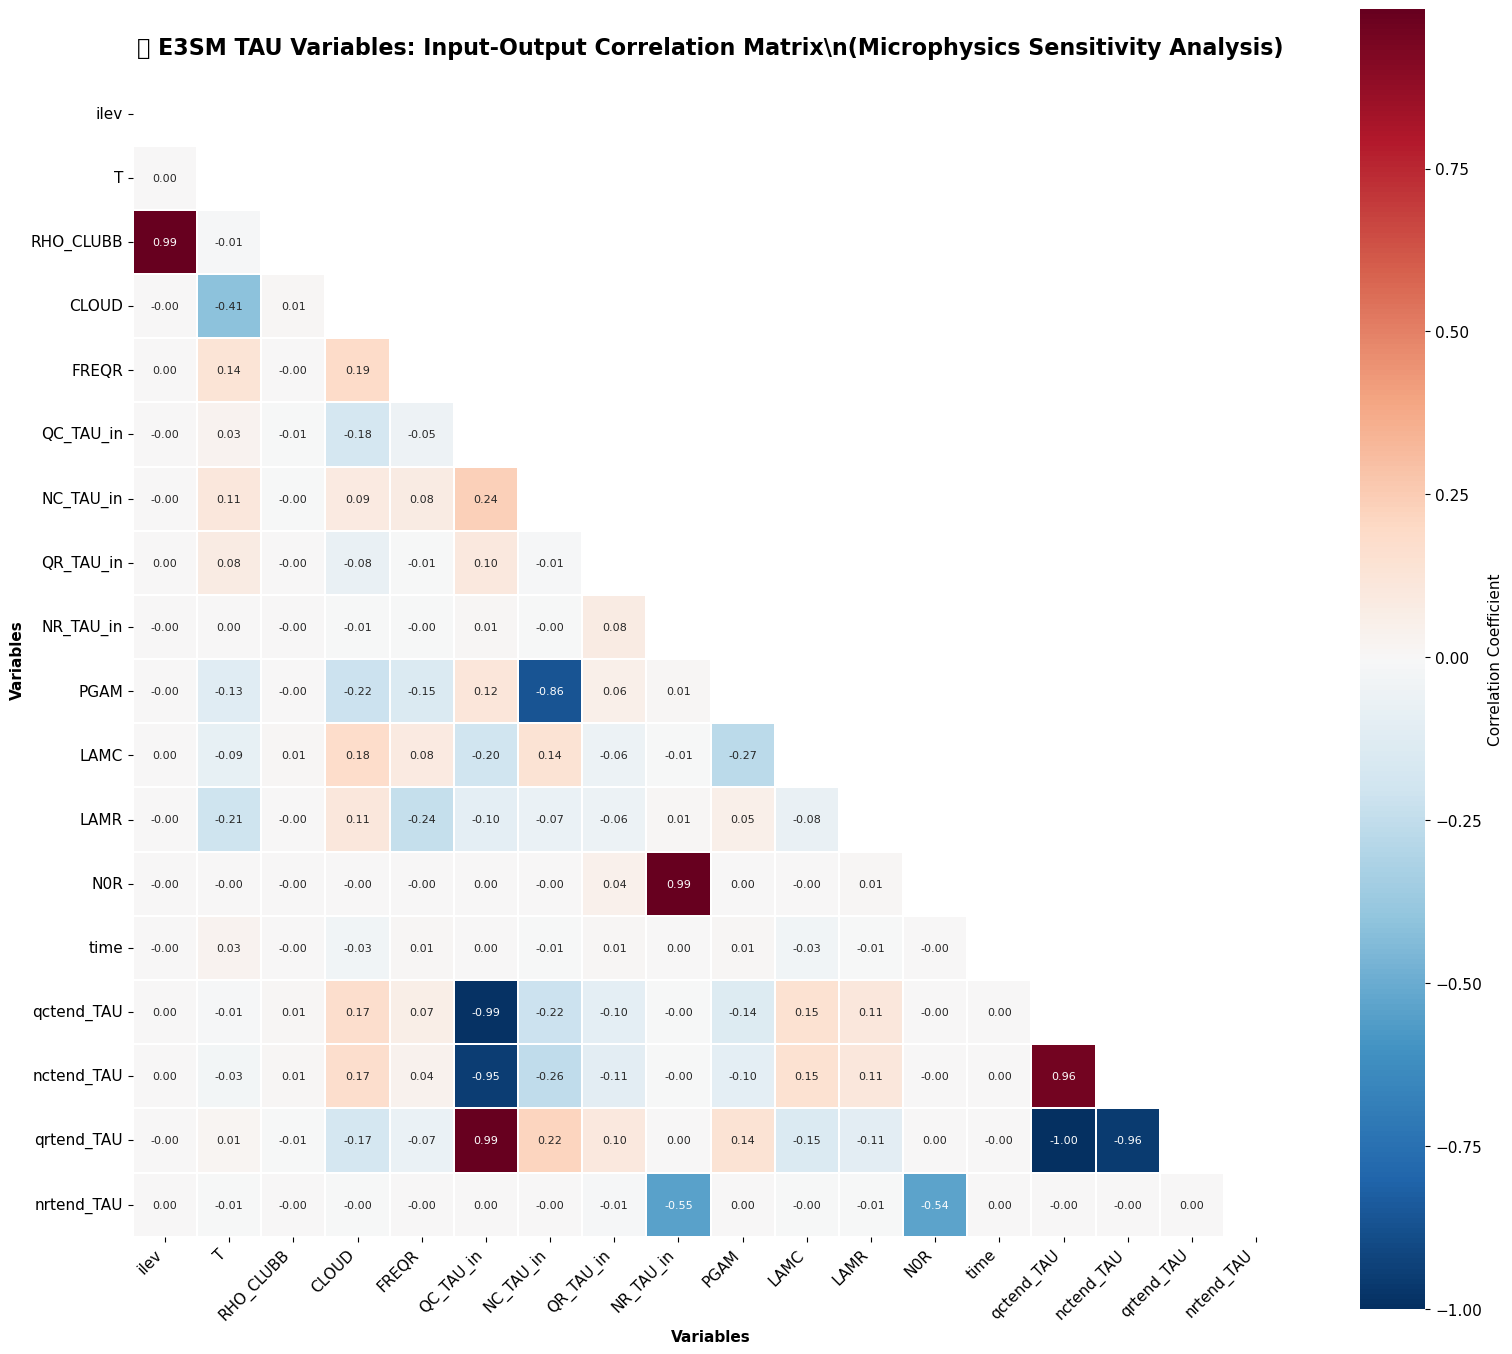


🎯 Strong correlations (|r| > 0.5):
   • ilev ↔ RHO_CLUBB: r = 0.995 (Input-Input)
   • QC_TAU_in ↔ qctend_TAU: r = -0.988 (Input-Output)
   • QC_TAU_in ↔ nctend_TAU: r = -0.951 (Input-Output)
   • QC_TAU_in ↔ qrtend_TAU: r = 0.988 (Input-Output)
   • NC_TAU_in ↔ PGAM: r = -0.861 (Input-Input)
   • NR_TAU_in ↔ N0R: r = 0.990 (Input-Input)
   • NR_TAU_in ↔ nrtend_TAU: r = -0.545 (Input-Output)
   • N0R ↔ nrtend_TAU: r = -0.540 (Input-Output)
   • qctend_TAU ↔ nctend_TAU: r = 0.957 (Output-Output)
   • qctend_TAU ↔ qrtend_TAU: r = -1.000 (Output-Output)
   • nctend_TAU ↔ qrtend_TAU: r = -0.957 (Output-Output)

🎯 Key Input → Output sensitivities (|r| > 0.3):
   • QC_TAU_in → qctend_TAU: r = -0.988
   • QC_TAU_in → qrtend_TAU: r = 0.988
   • QC_TAU_in → nctend_TAU: r = -0.951
   • NR_TAU_in → nrtend_TAU: r = -0.545
   • N0R → nrtend_TAU: r = -0.540

📈 Found 11 strong correlations total
🎯 Found 5 significant input-output relationships
Mass conversion is confirmed based on qrtend_TAU=-qctend

In [14]:
# Calculate correlation matrix for E3SM TAU variables
print("📊 E3SM TAU CORRELATION MATRIX ANALYSIS")
print("=" * 40)

# Combine all variables for correlation analysis
analysis_vars = input_vars + output_vars
correlation_data = combined_representative[analysis_vars].copy()

# Handle missing values
initial_rows = len(correlation_data)
correlation_data = correlation_data.dropna()
final_rows = len(correlation_data)
print(f"📊 Data points: {final_rows:,} (dropped {initial_rows-final_rows:,} rows with NaN)")

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Create correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0, 
            square=True,
            fmt='.2f',
            cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.3,
            annot_kws={'size': 8})

plt.title('🔗 E3SM TAU Variables: Input-Output Correlation Matrix\\n(Microphysics Sensitivity Analysis)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Variables', fontweight='bold')
plt.ylabel('Variables', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_matrix")
plt.show()

# Analyze strong correlations
print("\n🎯 Strong correlations (|r| > 0.5):")
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            var1_type = "Input" if var1 in input_vars else "Output"
            var2_type = "Input" if var2 in input_vars else "Output"
            relationship_type = f"{var1_type}-{var2_type}"
            strong_correlations.append((var1, var2, corr_val, relationship_type))
            print(f"   • {var1} ↔ {var2}: r = {corr_val:.3f} ({relationship_type})")

# Input-output sensitivities
print("\n🎯 Key Input → Output sensitivities (|r| > 0.3):")
input_output_correlations = []
for input_var in input_vars:
    for output_var in output_vars:
        corr_val = correlation_matrix.loc[input_var, output_var]
        if abs(corr_val) > 0.3:
            input_output_correlations.append((input_var, output_var, corr_val))

input_output_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
for input_var, output_var, corr_val in input_output_correlations[:10]:
    print(f"   • {input_var} → {output_var}: r = {corr_val:.3f}")

print(f"\n📈 Found {len(strong_correlations)} strong correlations total")
print(f"🎯 Found {len(input_output_correlations)} significant input-output relationships")
print(f"Mass conversion is confirmed based on qrtend_TAU=-qctend_TAU; implying only one of them needs to be predicted by emulator")
print("\n✅ Correlation analysis complete!")

## 🎯 Subtask 2.3: Input-Output Scatter Plot Analysis

🎯 E3SM TAU INPUT-OUTPUT SCATTER ANALYSIS
📊 Creating scatter plots for 6 key inputs vs 4 outputs
🔑 Key inputs: ['T', 'QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in', 'CLOUD']


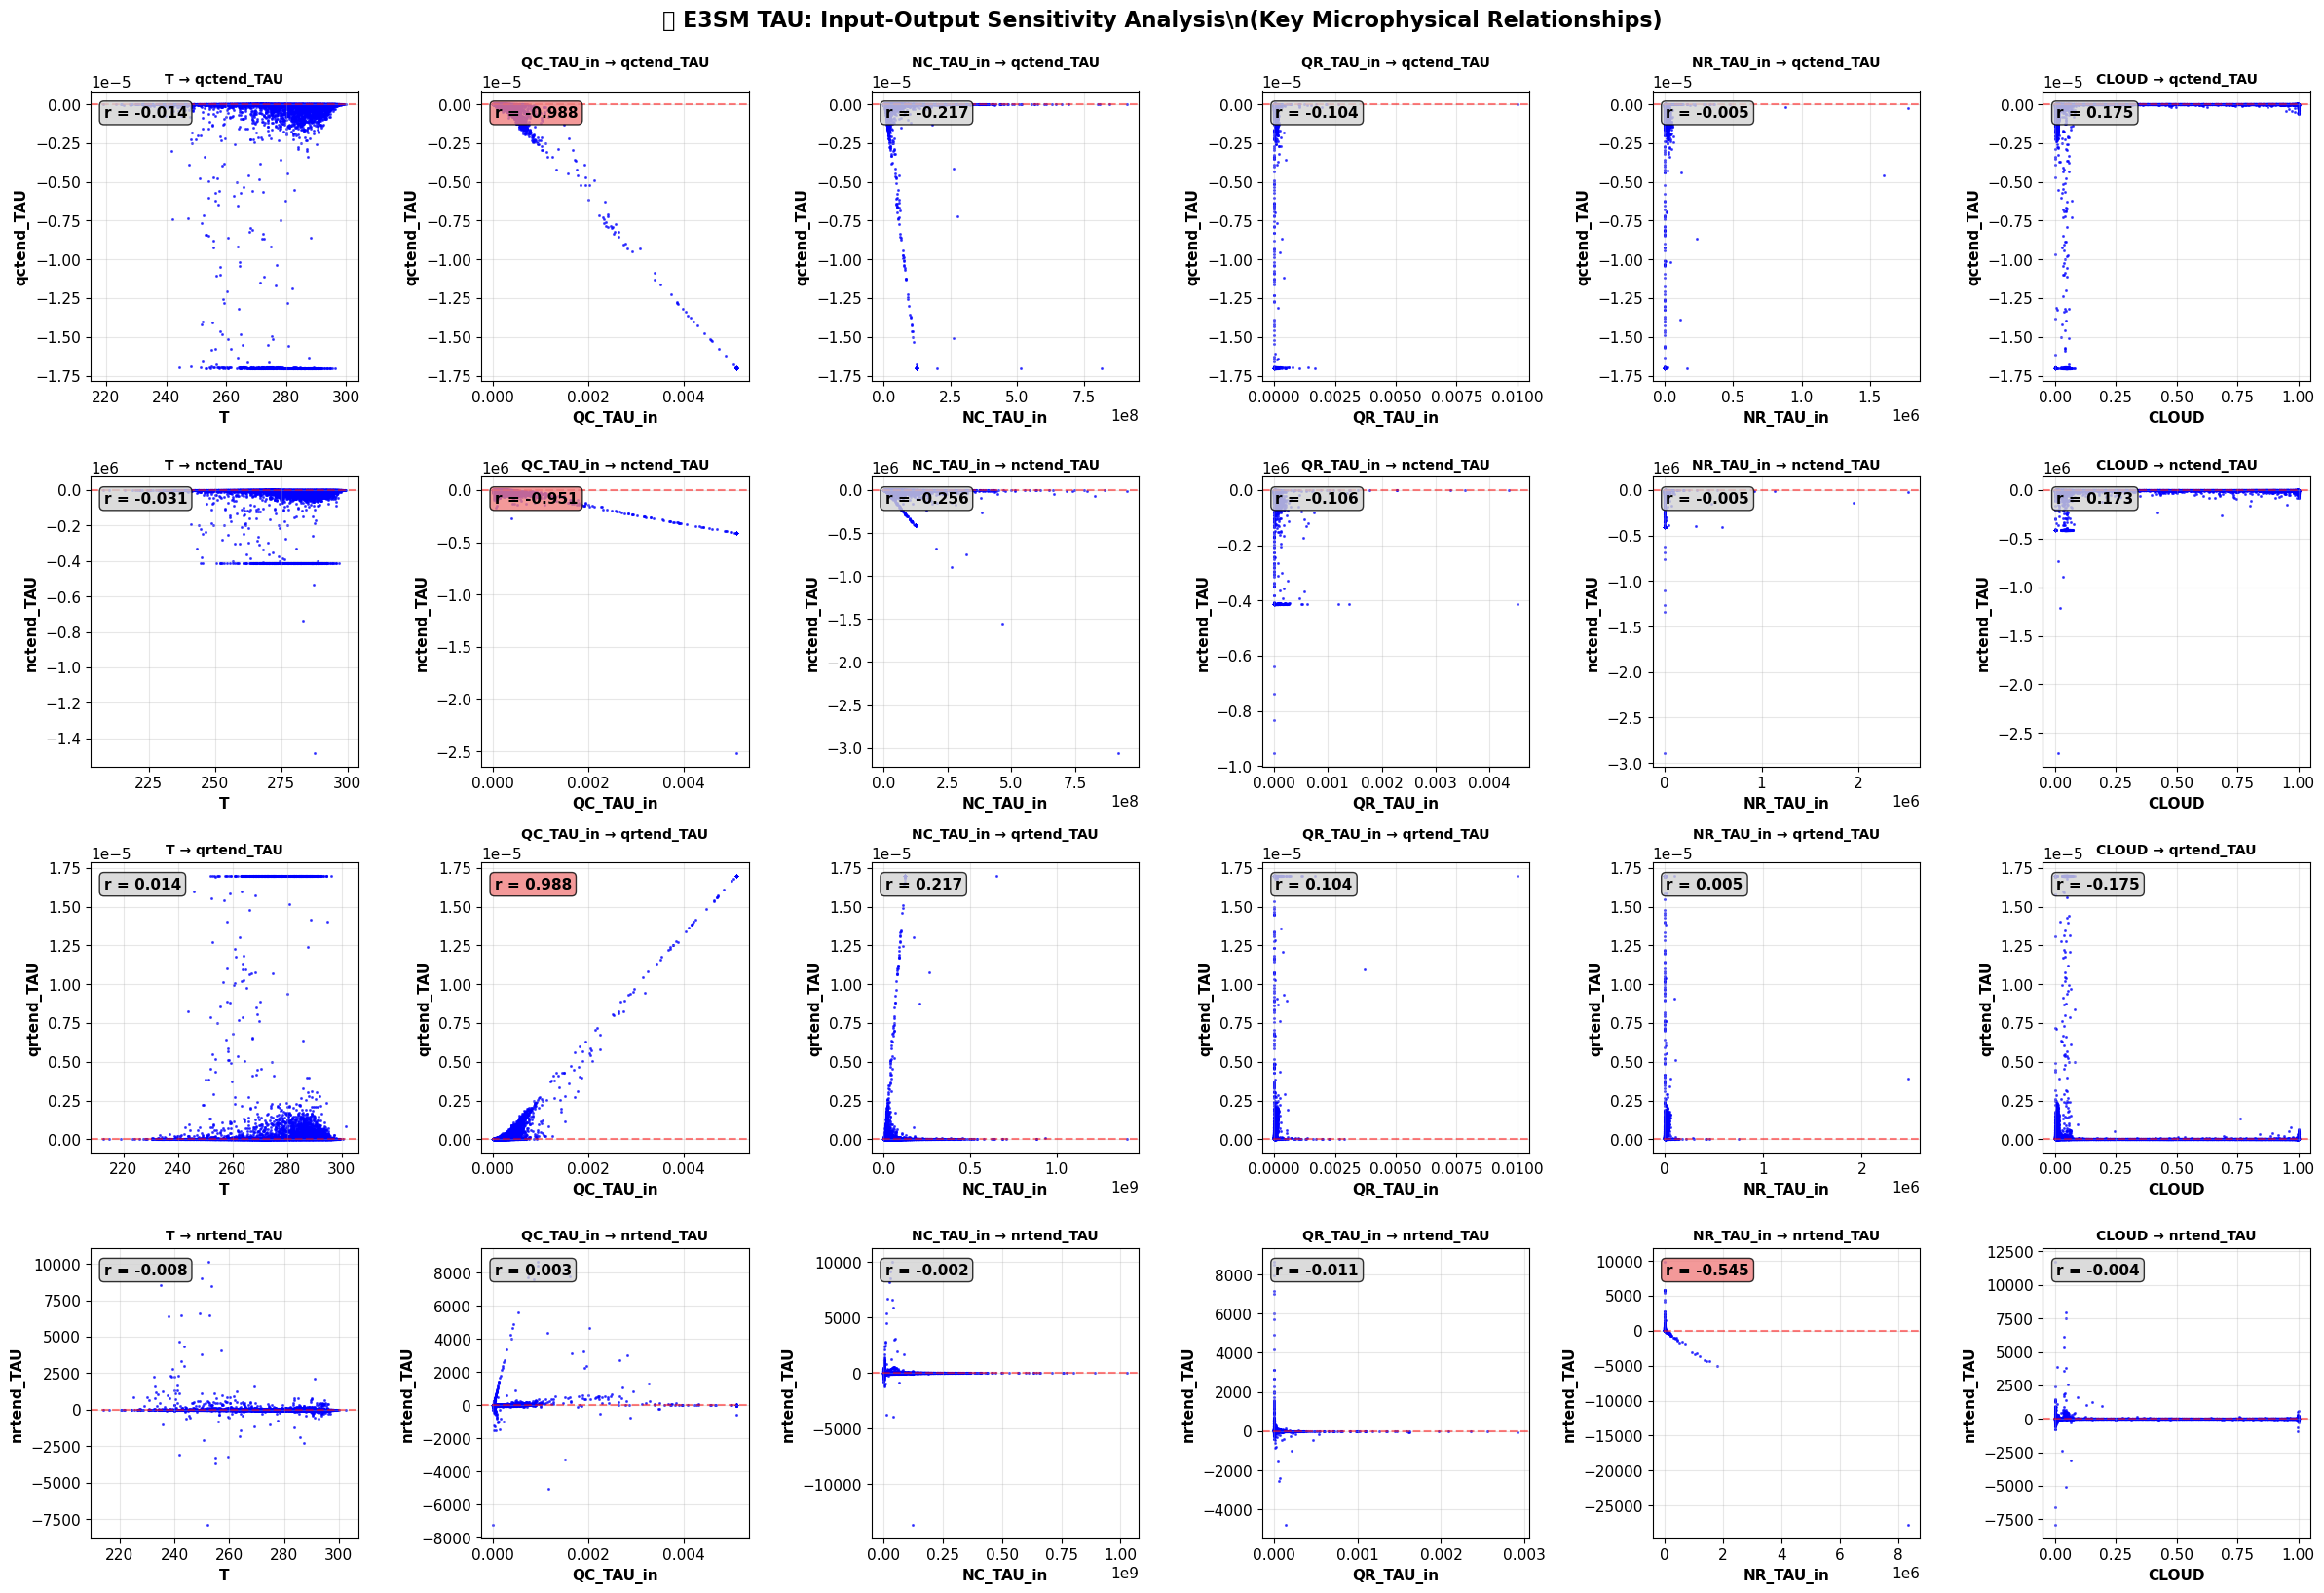


🏆 Strongest Relationships by Microphysical Process:

☁️ Cloud Mass Tendency (qctend_TAU):
   • QC_TAU_in → qctend_TAU: r = -0.988
   • NC_TAU_in → qctend_TAU: r = -0.217
   • CLOUD → qctend_TAU: r = 0.175
   • QR_TAU_in → qctend_TAU: r = -0.104
   • T → qctend_TAU: r = -0.014
   • NR_TAU_in → qctend_TAU: r = -0.005

🌧️ Rain Mass Tendency (qrtend_TAU):
   • QC_TAU_in → qrtend_TAU: r = 0.988
   • NC_TAU_in → qrtend_TAU: r = 0.217
   • CLOUD → qrtend_TAU: r = -0.175
   • QR_TAU_in → qrtend_TAU: r = 0.104
   • T → qrtend_TAU: r = 0.014
   • NR_TAU_in → qrtend_TAU: r = 0.005

☁️ Cloud Number Tendency (nctend_TAU):
   • QC_TAU_in → nctend_TAU: r = -0.951
   • NC_TAU_in → nctend_TAU: r = -0.256
   • CLOUD → nctend_TAU: r = 0.173
   • QR_TAU_in → nctend_TAU: r = -0.106
   • T → nctend_TAU: r = -0.031
   • NR_TAU_in → nctend_TAU: r = -0.005

🌧️ Rain Number Tendency (nrtend_TAU):
   • NR_TAU_in → nrtend_TAU: r = -0.545
   • QR_TAU_in → nrtend_TAU: r = -0.011
   • T → nrtend_TAU: r = -0.008
   •

In [15]:
# Create scatter plots for key input-output relationships
print("🎯 E3SM TAU INPUT-OUTPUT SCATTER ANALYSIS")
print("=" * 45)

# Focus on most important relationships to avoid too many plots
key_inputs = ['T', 'QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in', 'CLOUD']
key_inputs = [var for var in key_inputs if var in input_vars]  # Only available ones

print(f"📊 Creating scatter plots for {len(key_inputs)} key inputs vs {len(output_vars)} outputs")
print(f"🔑 Key inputs: {key_inputs}")

# Create scatter plot grid
fig, axes = plt.subplots(len(output_vars), len(key_inputs), 
                        figsize=(4*len(key_inputs), 4*len(output_vars)))

# Handle single row/column cases
if len(output_vars) == 1 and len(key_inputs) == 1:
    axes = [[axes]]
elif len(output_vars) == 1:
    axes = [axes]
elif len(key_inputs) == 1:
    axes = [[ax] for ax in axes]

scatter_correlations = {}

for i, output_var in enumerate(output_vars):
    for j, input_var in enumerate(key_inputs):
        ax = axes[i][j]
        
        # Get clean data
        x_data = combined_representative[input_var]
        y_data = combined_representative[output_var]
        valid_mask = ~(pd.isna(x_data) | pd.isna(y_data))
        x_clean = x_data[valid_mask]
        y_clean = y_data[valid_mask]
        
        # Sample for visualization if large dataset
        if len(x_clean) > 15000:
            sample_idx = np.random.choice(len(x_clean), 15000, replace=False)
            x_plot = x_clean.iloc[sample_idx]
            y_plot = y_clean.iloc[sample_idx]
        else:
            x_plot = x_clean
            y_plot = y_clean
        
        # Create scatter plot
        ax.scatter(x_plot, y_plot, alpha=0.6, s=1.5, c='blue')
        ax.set_xlabel(f'{input_var}', fontweight='bold')
        ax.set_ylabel(f'{output_var}', fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Calculate correlation
        if len(x_clean) > 1:
            corr_coef = np.corrcoef(x_clean, y_clean)[0, 1]
            scatter_correlations[f'{input_var}_vs_{output_var}'] = corr_coef
            
            # Color-code correlation strength
            if abs(corr_coef) > 0.5:
                bbox_color = 'lightcoral'
            elif abs(corr_coef) > 0.3:
                bbox_color = 'lightblue' 
            else:
                bbox_color = 'lightgray'
            
            ax.text(0.05, 0.95, f'r = {corr_coef:.3f}', 
                   transform=ax.transAxes, 
                   bbox=dict(boxstyle='round', facecolor=bbox_color, alpha=0.8),
                   verticalalignment='top', fontweight='bold')
        
        # Add zero line for tendencies
        if 'tend' in output_var:
            ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
        ax.set_title(f'{input_var} → {output_var}', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle('🎯 E3SM TAU: Input-Output Sensitivity Analysis\\n(Key Microphysical Relationships)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig("input_output_sensitivities")
plt.show()

# Analyze by process type
print("\n🏆 Strongest Relationships by Microphysical Process:")
sorted_correlations = sorted(scatter_correlations.items(), 
                           key=lambda x: abs(x[1]), reverse=True)

print("\n☁️ Cloud Mass Tendency (qctend_TAU):")
for relationship, corr in sorted_correlations:
    if 'qctend' in relationship:
        input_var, output_var = relationship.split('_vs_')
        print(f"   • {input_var} → {output_var}: r = {corr:.3f}")

print("\n🌧️ Rain Mass Tendency (qrtend_TAU):")
for relationship, corr in sorted_correlations:
    if 'qrtend' in relationship:
        input_var, output_var = relationship.split('_vs_')
        print(f"   • {input_var} → {output_var}: r = {corr:.3f}")

print("\n☁️ Cloud Number Tendency (nctend_TAU):")
for relationship, corr in sorted_correlations:
    if 'nctend' in relationship:
        input_var, output_var = relationship.split('_vs_')
        print(f"   • {input_var} → {output_var}: r = {corr:.3f}")

print("\n🌧️ Rain Number Tendency (nrtend_TAU):")
for relationship, corr in sorted_correlations:
    if 'nrtend' in relationship:
        input_var, output_var = relationship.split('_vs_')
        print(f"   • {input_var} → {output_var}: r = {corr:.3f}")

print("\n✅ Scatter plot analysis complete!")

## 🌡️ Subtask 2.4: Multi-Regime Conditional Analysis

In [16]:
# Analyze relationships under different physical regimes
print("🌡️ MULTI-REGIME CONDITIONAL ANALYSIS")
print("=" * 40)

# Define multiple regime types for comprehensive analysis
regime_definitions = {}

# 1. Temperature regimes
if 'T' in input_vars:
    temp_data = combined_representative['T']
    temp_percentiles = [25, 50, 75]
    temp_thresholds = [temp_data.quantile(p/100) for p in temp_percentiles]
    
    regime_definitions['Temperature'] = {
        'Cold': temp_data <= temp_thresholds[0],
        'Cool': (temp_data > temp_thresholds[0]) & (temp_data <= temp_thresholds[1]),
        'Warm': (temp_data > temp_thresholds[1]) & (temp_data <= temp_thresholds[2]),
        'Hot': temp_data > temp_thresholds[2]
    }
    print(f"🌡️ Temperature regimes: {temp_thresholds[0]:.1f}K - {temp_thresholds[2]:.1f}K")

# 2. Pressure/Level regimes  
if 'ilev' in input_vars:
    level_data = combined_representative['ilev']
    level_percentiles = [25, 50, 75]
    level_thresholds = [level_data.quantile(p/100) for p in level_percentiles]
    
    regime_definitions['Pressure_Level'] = {
        'Upper_Atmosphere': level_data <= level_thresholds[0],
        'Mid_Atmosphere': (level_data > level_thresholds[0]) & (level_data <= level_thresholds[2]),
        'Lower_Atmosphere': level_data > level_thresholds[2]
    }
    print(f"🏔️ Pressure regimes: {level_data.min():.0f} - {level_data.max():.0f}")

# 3. Cloud-Rain regimes (microphysical)
if 'QC_TAU_in' in input_vars and 'QR_TAU_in' in input_vars:
    qc_data = combined_representative['QC_TAU_in']
    qr_data = combined_representative['QR_TAU_in']
    qc_threshold = qc_data.quantile(0.1)
    qr_threshold = qr_data.quantile(0.1)
    
    regime_definitions['Microphysical'] = {
        'Clear_Sky': (qc_data <= qc_threshold) & (qr_data <= qr_threshold),
        'Cloud_Only': (qc_data > qc_threshold) & (qr_data <= qr_threshold),
        'Precipitating': (qc_data > qc_threshold) & (qr_data > qr_threshold),
        'Rain_Only': (qc_data <= qc_threshold) & (qr_data > qr_threshold)
    }
    print(f"☁️ Microphysical regimes: qc>{qc_threshold:.2e}, qr>{qr_threshold:.2e}")

# 4. Cloud fraction regimes
if 'CLOUD' in input_vars:
    cloud_data = combined_representative['CLOUD']
    regime_definitions['Cloud_Fraction'] = {
        'Clear': cloud_data <= 0.005,
        'Partly_Cloudy': (cloud_data > 0.005) & (cloud_data <= 0.8),
        'Overcast': cloud_data > 0.8
    }
    print(f"☁️ Cloud fraction regimes: 0-0.005, 0.005-0.8, 0.8-1.0")

# Analyze correlations within each regime type
regime_analysis = {}

for regime_type, regimes in regime_definitions.items():
    print(f"\n📊 {regime_type} Regime Analysis:")
    print("-" * 40)
    
    regime_correlations = {}
    
    for regime_name, regime_mask in regimes.items():
        regime_data = combined_representative[regime_mask]
        count = regime_mask.sum()
        percentage = (count / len(combined_representative)) * 100
        
        print(f"\n🎯 {regime_name}: {count:,} samples ({percentage:.1f}%)")
        
        if count > 100:  # Sufficient data for analysis
            regime_corr = {}
            
            # Calculate key input-output correlations for this regime
            key_relationships = [
                ('QC_TAU_in', 'qctend_TAU'),
                ('QC_TAU_in', 'qrtend_TAU'), 
                ('NC_TAU_in', 'nctend_TAU'),
                ('QR_TAU_in', 'qrtend_TAU'),
                ('T', 'qctend_TAU'),
                ('T', 'qrtend_TAU')
            ]
            
            for input_var, output_var in key_relationships:
                if input_var in regime_data.columns and output_var in regime_data.columns:
                    x = regime_data[input_var].dropna()
                    y = regime_data[output_var].dropna()
                    common_idx = x.index.intersection(y.index)
                    
                    if len(common_idx) > 50:
                        corr = np.corrcoef(x[common_idx], y[common_idx])[0, 1]
                        regime_corr[f'{input_var}_vs_{output_var}'] = corr
                        
                        if abs(corr) > 0.3:  # Only show significant correlations
                            print(f"   • {input_var} → {output_var}: r = {corr:.3f}")
            
            regime_correlations[regime_name] = regime_corr
    
    regime_analysis[regime_type] = regime_correlations

# Identify regime-dependent relationships
print(f"\n🔍 REGIME-DEPENDENT SENSITIVITY ANALYSIS:")
print("=" * 45)

for regime_type, regime_correlations in regime_analysis.items():
    print(f"\n📊 {regime_type} regime variability:")
    
    # Find relationships that vary significantly across regimes
    all_relationships = set()
    for regime_corrs in regime_correlations.values():
        all_relationships.update(regime_corrs.keys())
    
    regime_variability = {}
    for relationship in all_relationships:
        regime_corrs = []
        for regime_name, regime_data in regime_correlations.items():
            if relationship in regime_data:
                regime_corrs.append(regime_data[relationship])
        
        if len(regime_corrs) >= 2:
            variability = max(regime_corrs) - min(regime_corrs)
            regime_variability[relationship] = variability
    
    # Show most variable relationships
    most_variable = sorted(regime_variability.items(), 
                          key=lambda x: x[1], reverse=True)[:3]
    
    for relationship, variability in most_variable:
        if variability > 0.2:  # Only significant variations
            input_var, output_var = relationship.split('_vs_')
            print(f"   • {input_var} → {output_var}: Δr = {variability:.3f}")

print("\n✅ Multi-regime conditional analysis complete!")

🌡️ MULTI-REGIME CONDITIONAL ANALYSIS
🌡️ Temperature regimes: 268.4K - 286.1K
🏔️ Pressure regimes: 0 - 1000
☁️ Microphysical regimes: qc>8.35e-07, qr>1.82e-12
☁️ Cloud fraction regimes: 0-0.005, 0.005-0.8, 0.8-1.0

📊 Temperature Regime Analysis:
----------------------------------------

🎯 Cold: 18,750,058 samples (25.0%)
   • QC_TAU_in → qctend_TAU: r = -0.985
   • QC_TAU_in → qrtend_TAU: r = 0.985
   • NC_TAU_in → nctend_TAU: r = -0.301

🎯 Cool: 18,749,968 samples (25.0%)
   • QC_TAU_in → qctend_TAU: r = -0.992
   • QC_TAU_in → qrtend_TAU: r = 0.992

🎯 Warm: 18,749,978 samples (25.0%)
   • QC_TAU_in → qctend_TAU: r = -0.990
   • QC_TAU_in → qrtend_TAU: r = 0.990

🎯 Hot: 18,749,996 samples (25.0%)
   • QC_TAU_in → qctend_TAU: r = -0.986
   • QC_TAU_in → qrtend_TAU: r = 0.986

📊 Pressure_Level Regime Analysis:
----------------------------------------

🎯 Upper_Atmosphere: 19,454,660 samples (25.9%)
   • QC_TAU_in → qctend_TAU: r = -0.988
   • QC_TAU_in → qrtend_TAU: r = 0.988

🎯 Mid_Atmos

## 🔬 Subtask 2.5: Process-Specific Analysis

In [17]:
# Analyze autoconversion vs collection processes
print("🔬 PROCESS-SPECIFIC ANALYSIS: AUTOCONVERSION vs COLLECTION")
print("=" * 60)

# Define process indicators based on tendency signs and magnitudes
process_analysis = {}

if 'qctend_TAU' in output_vars and 'qrtend_TAU' in output_vars:
    qc_tend = combined_representative['qctend_TAU']
    qr_tend = combined_representative['qrtend_TAU']
    
    # Define process regimes based on tendency patterns
    # Autoconversion: cloud mass decreases, rain mass increases
    # Collection: both cloud and rain can change in various ways
    
    process_regimes = {
        'Autoconversion': (qc_tend < 0) & (qr_tend > 0) & (abs(qc_tend) > 1e-10),
        'Evaporation': (qc_tend < 0) & (qr_tend < 0),
        'Condensation': (qc_tend > 0) & (qr_tend < abs(qc_tend)/2),  # More cloud growth than rain
        'Collection': (qr_tend > 0) & (qc_tend < 0) & (qr_tend > abs(qc_tend)),  # Rain growth > cloud loss
        'Quiescent': (abs(qc_tend) < 1e-12) & (abs(qr_tend) < 1e-12)
    }
    
    print(f"🔍 Process regime distribution:")
    process_stats = {}
    
    for process, mask in process_regimes.items():
        count = mask.sum()
        percentage = (count / len(combined_representative)) * 100
        process_stats[process] = {'count': count, 'percentage': percentage}
        print(f"   • {process}: {count:,} samples ({percentage:.1f}%)")
    
    # Analyze input sensitivity for each process
    print(f"\n📊 INPUT SENSITIVITY BY PROCESS:")
    print("=" * 35)
    
    key_process_inputs = ['QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in', 'T', 'LAMC', 'LAMR']
    key_process_inputs = [var for var in key_process_inputs if var in input_vars]
    
    for process_name, process_mask in process_regimes.items():
        if process_stats[process_name]['count'] > 500:  # Sufficient data
            print(f"\n🔬 {process_name} Process ({process_stats[process_name]['percentage']:.1f}%):")
            
            process_data = combined_representative[process_mask]
            
            # Calculate correlations with key inputs
            process_correlations = []
            
            for input_var in key_process_inputs:
                for output_var in ['qctend_TAU', 'qrtend_TAU']:
                    if output_var in output_vars:
                        x = process_data[input_var].dropna()
                        y = process_data[output_var].dropna()
                        common_idx = x.index.intersection(y.index)
                        
                        if len(common_idx) > 100:
                            corr = np.corrcoef(x[common_idx], y[common_idx])[0, 1]
                            if abs(corr) > 0.2:
                                process_correlations.append((input_var, output_var, corr))
            
            # Sort by correlation strength
            process_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
            
            # Show top correlations for this process
            for input_var, output_var, corr in process_correlations[:5]:
                print(f"   • {input_var} → {output_var}: r = {corr:.3f}")

else:
    print("⚠️ Tendency variables not available for process analysis")

# Autoconversion threshold analysis
print(f"\n🎯 AUTOCONVERSION THRESHOLD ANALYSIS:")
print("=" * 40)

if 'QC_TAU_in' in input_vars and 'NC_TAU_in' in input_vars and 'qrtend_TAU' in output_vars:
    # Calculate mean droplet size (qc/Nc)
    qc_data = combined_representative['QC_TAU_in']
    nc_data = combined_representative['NC_TAU_in']
    qr_tend = combined_representative['qrtend_TAU']
    
    # Avoid division by zero
    valid_mask = (nc_data > 1e-10) & (qc_data > 1e-15)
    mean_droplet_size = qc_data[valid_mask] / nc_data[valid_mask]
    qr_tend_filtered = qr_tend[valid_mask]
    
    # Define autoconversion onset
    autoconv_mask = qr_tend_filtered > 1e-10  # Positive rain tendency
    
    if autoconv_mask.sum() > 100:
        autoconv_threshold = mean_droplet_size[autoconv_mask].quantile(0.1)
        no_autoconv_threshold = mean_droplet_size[~autoconv_mask].quantile(0.9)
        
        print(f"📊 Mean droplet size analysis:")
        print(f"   • Autoconversion threshold: {autoconv_threshold:.2e} kg/droplet")
        print(f"   • No-autoconversion upper bound: {no_autoconv_threshold:.2e} kg/droplet")
        
        # Correlation with rain tendency
        corr_droplet_rain = np.corrcoef(mean_droplet_size, qr_tend_filtered)[0, 1]
        print(f"   • Correlation (droplet size vs rain tendency): r = {corr_droplet_rain:.3f}")

print("\n✅ Process-specific analysis complete!")

🔬 PROCESS-SPECIFIC ANALYSIS: AUTOCONVERSION vs COLLECTION
🔍 Process regime distribution:
   • Autoconversion: 33,969,271 samples (45.3%)
   • Evaporation: 0 samples (0.0%)
   • Condensation: 0 samples (0.0%)
   • Collection: 262,058 samples (0.3%)
   • Quiescent: 30,817,420 samples (41.1%)

📊 INPUT SENSITIVITY BY PROCESS:

🔬 Autoconversion Process (45.3%):
   • QC_TAU_in → qctend_TAU: r = -0.993
   • QC_TAU_in → qrtend_TAU: r = 0.993
   • NC_TAU_in → qctend_TAU: r = -0.328
   • NC_TAU_in → qrtend_TAU: r = 0.328
   • LAMC → qctend_TAU: r = 0.210

🔬 Collection Process (0.3%):

🔬 Quiescent Process (41.1%):

🎯 AUTOCONVERSION THRESHOLD ANALYSIS:
📊 Mean droplet size analysis:
   • Autoconversion threshold: 8.26e-13 kg/droplet
   • No-autoconversion upper bound: 4.13e-11 kg/droplet
   • Correlation (droplet size vs rain tendency): r = 0.252

✅ Process-specific analysis complete!


In [30]:
print("🔬 PROCESS-SPECIFIC ANALYSIS")
print("=" * 60)

qr_initial_threshold = 1e-9  # A small value to represent negligible initial rain

# 1. First, separate the data into Quiescent (inactive) and Active cases
quiescent_mask = (abs(combined_representative['qctend_TAU']) < 1e-12)
active_mask = ~quiescent_mask

# 2. Within the active cases, separate them based on initial rain conditions
autoconversion_mask = active_mask & (combined_representative['QR_TAU_in'] < qr_initial_threshold)
accretion_mask = active_mask & (combined_representative['QR_TAU_in'] >= qr_initial_threshold)

# Define the new, robust process regimes
process_regimes = {
    'Quiescent': quiescent_mask,
    'Autoconversion-Dominated': autoconversion_mask,
    'Accretion-Dominated': accretion_mask
}


print(f"🔍 Process regime distribution:")
total_samples = len(combined_representative)
process_stats = {}
for process, mask in process_regimes.items():
    count = mask.sum()
    percentage = (count / total_samples) * 100
    process_stats[process] = {'count': count, 'percentage': percentage}
    print(f"• {process}: {count:,} samples ({percentage:.1f}%)")


    
# Analyze input sensitivity for each process
print(f"\n📊 INPUT SENSITIVITY BY PROCESS:")
print("=" * 35)

key_process_inputs = ['QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in', 'T', 'LAMC', 'LAMR']
key_process_inputs = [var for var in key_process_inputs if var in input_vars]

for process_name, process_mask in process_regimes.items():
    if process_stats[process_name]['count'] > 500:  # Sufficient data
        print(f"\n🔬 {process_name} Process ({process_stats[process_name]['percentage']:.1f}%):")        
        process_data = combined_representative[process_mask]
        
        # Calculate correlations with key inputs
        process_correlations = []
        
        for input_var in key_process_inputs:
            for output_var in ['qctend_TAU', 'qrtend_TAU']:
                if output_var in output_vars:
                    x = process_data[input_var].dropna()
                    y = process_data[output_var].dropna()
                    common_idx = x.index.intersection(y.index)
                    
                    if len(common_idx) > 100:
                        corr = np.corrcoef(x[common_idx], y[common_idx])[0, 1]
                        if abs(corr) > 0.2:
                            process_correlations.append((input_var, output_var, corr))
        
        # Sort by correlation strength
        process_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
        
        # Show top correlations for this process
        for input_var, output_var, corr in process_correlations[:5]:
            print(f"   • {input_var} → {output_var}: r = {corr:.3f}")



# Autoconversion threshold analysis
print(f"\n🎯 AUTOCONVERSION THRESHOLD ANALYSIS:")
print("=" * 40)
# --- Define Physical Constants ---
rho_water = 1000.0  # Density of water in kg/m^3
if 'QC_TAU_in' in input_vars and 'NC_TAU_in' in input_vars and 'qrtend_TAU' in output_vars:
    # Calculate mean droplet size (qc/Nc)
    qc_data = combined_representative['QC_TAU_in']
    nc_data = combined_representative['NC_TAU_in']
    qr_tend = combined_representative['qrtend_TAU']
    
    # Avoid division by zero
    valid_mask = (nc_data > 1e-10) & (qc_data > 1e-15)
    mean_droplet_mass = qc_data[valid_mask] / nc_data[valid_mask]
    qr_tend_filtered = qr_tend[valid_mask]

    # Convert mass to radius in meters using the formula: r = ( (3*m) / (4*pi*rho) )^(1/3)
    mean_droplet_radius_m = ( (3 * mean_droplet_mass) / (4 * np.pi * rho_water) )**(1/3)    
    # Convert radius from meters to micrometers (1m = 1e6 um)
    mean_droplet_radius_um = mean_droplet_radius_m * 1e6
    
    # Define autoconversion onset
    autoconv_mask = qr_tend_filtered > 1e-10  # Positive rain tendency
    
    if autoconv_mask.sum() > 100:
        autoconv_threshold = mean_droplet_radius_um[autoconv_mask].quantile(0.1)
        no_autoconv_threshold = mean_droplet_radius_um[~autoconv_mask].quantile(0.9)
        
        print(f"📊 Mean droplet size analysis:")
        print(f"   • Autoconversion threshold: {autoconv_threshold:.2e} micrometer")
        print(f"   • No-autoconversion upper bound: {no_autoconv_threshold:.2e} micrometer")
        
        # Correlation with rain tendency
        corr_droplet_rain = np.corrcoef(mean_droplet_radius_um, qr_tend_filtered)[0, 1]
        print(f"   • Correlation (droplet size vs rain tendency): r = {corr_droplet_rain:.3f}")

print("\n✅ Process-specific analysis complete!")

🔬 PROCESS-SPECIFIC ANALYSIS
🔍 Process regime distribution:
• Quiescent: 30,817,420 samples (41.1%)
• Autoconversion-Dominated: 2,930,534 samples (3.9%)
• Accretion-Dominated: 41,252,046 samples (55.0%)

📊 INPUT SENSITIVITY BY PROCESS:

🔬 Quiescent Process (41.1%):

🔬 Autoconversion-Dominated Process (3.9%):
   • QC_TAU_in → qctend_TAU: r = -0.990
   • QC_TAU_in → qrtend_TAU: r = 0.990
   • NC_TAU_in → qctend_TAU: r = -0.566
   • NC_TAU_in → qrtend_TAU: r = 0.566

🔬 Accretion-Dominated Process (55.0%):
   • QC_TAU_in → qctend_TAU: r = -0.991
   • QC_TAU_in → qrtend_TAU: r = 0.991
   • NC_TAU_in → qctend_TAU: r = -0.273
   • NC_TAU_in → qrtend_TAU: r = 0.273
   • LAMC → qctend_TAU: r = 0.202

🎯 AUTOCONVERSION THRESHOLD ANALYSIS:
📊 Mean droplet size analysis:
   • Autoconversion threshold: 5.82e+00 micrometer
   • No-autoconversion upper bound: 2.14e+01 micrometer
   • Correlation (droplet size vs rain tendency): r = 0.236

✅ Process-specific analysis complete!


## 📋 Subtask 2.6: Phase 2 Summary and ML Architecture Guidance

In [19]:
# Phase 2 Summary: E3SM TAU Input-Output Sensitivity Analysis
print("🎯 PHASE 2: E3SM TAU INPUT-OUTPUT SENSITIVITY - SUMMARY")
print("=" * 65)

print("\n📊 ANALYSIS SCOPE:")
print("-" * 20)
print(f"📥 Input variables: {len(input_vars)}")
print(f"   • Environmental: T, RHO_CLUBB, CLOUD, FREQR, ilev")
print(f"   • Microphysical: QC_TAU_in, NC_TAU_in, QR_TAU_in, NR_TAU_in")
print(f"   • Distribution: PGAM, LAMC, LAMR, N0R")
print(f"📤 Output variables: {len(output_vars)} (tendencies)")
print(f"   • Mass: qctend_TAU, qrtend_TAU")
print(f"   • Number: nctend_TAU, nrtend_TAU")
print(f"🔗 Relationships analyzed: {len(input_vars) * len(output_vars)}")
print(f"📊 Data points: {len(combined_representative):,}")

print("\n🏆 KEY FINDINGS:")
print("-" * 15)

# Top relationships
if 'scatter_correlations' in locals():
    print("\n1️⃣ STRONGEST INPUT-OUTPUT RELATIONSHIPS:")
    top_relationships = sorted(scatter_correlations.items(), 
                             key=lambda x: abs(x[1]), reverse=True)[:5]
    for i, (relationship, corr) in enumerate(top_relationships, 1):
        input_var, output_var = relationship.split('_vs_')
        print(f"   {i}. {input_var} → {output_var}: r = {corr:.3f}")

# Regime insights
if 'regime_definitions' in locals():
    print(f"\n2️⃣ REGIME-DEPENDENT BEHAVIOR:")
    print(f"   • Analyzed {len(regime_definitions)} regime types:")
    for regime_type in regime_definitions.keys():
        print(f"     - {regime_type}")
    print(f"   • Significant regime-dependent correlations identified")

# Process insights
if 'process_stats' in locals():
    print(f"\n3️⃣ MICROPHYSICAL PROCESSES:")
    for process, stats in process_stats.items():
        if stats['percentage'] > 5:  # Show major processes
            print(f"   • {process}: {stats['percentage']:.1f}% of data")

print("\n\n🎯 ML ARCHITECTURE RECOMMENDATIONS:")
print("-" * 40)

print("\n1. 🏗️ MODEL ARCHITECTURE:")
print("   • Multi-head architecture for each tendency type")
print("   • Separate processing branches for different regimes")
print(" 🧠 Choose ReLU-like Activations to capture complex, non-linear relationships and avoid saturation in the tails of the data distribution")
if 'process_stats' in locals():
    print("   • Process-specific sub-networks (autoconversion vs collection)")
print("   • Perhaps add Physics constraints: mass conservation (qctend + qrtend ≈ 0)")

print("\n2. 📊 PREPROCESSING PIPELINE:")
print("   • Log₁₀ transform: QC_TAU_in, NC_TAU_in, QR_TAU_in, NR_TAU_in")
print("   • Log₁₀ transform: LAMC, LAMR, N0R (distribution parameters)")
print("   • StandardScaler for: T, RHO_CLUBB, ilev")
print("   • MinMaxScaler for: CLOUD, FREQR (fraction variables)")
print("   • Tendency preprocessing: log₁₀(|tend| + ε) with sign preservation")

print("\n3. 🎯 FEATURE ENGINEERING:")
# Most predictive inputs
if 'top_relationships' in locals():
    most_predictive = set()
    for relationship, corr in top_relationships:
        input_var = relationship.split('_vs_')[0]
        most_predictive.add(input_var)
    print(f"   • Prioritize: {list(most_predictive)}")

print("   • Derived features:")
print("     - Mean droplet size: QC_TAU_in / NC_TAU_in")
print("     - Mean raindrop size: QR_TAU_in / NR_TAU_in")
print("     - Supersaturation proxy: function(T, RHO_CLUBB)")
print("   • Regime indicators as categorical features")

print("\n4. 🏋️ TRAINING STRATEGY:")
if 'regime_definitions' in locals():
    print("   • Stratified sampling across regime types")
if 'process_stats' in locals():
    print("   • Balanced sampling across microphysical processes")
print("   • Multi-task learning")
print("  • Combination of classification and regression loss function")
#print("   • Physics penalty: λ * |qctend + qrtend|²")
#print("   • Sign-aware loss functions for tendencies")

print("\n5. 📈 EVALUATION METRICS:")
print("   • Process-specific R² and RMSE")
print("   • Mass conservation error")
print("   • Regime-stratified performance")
print("   • Physical bounds validation")
print("   • Autoconversion threshold accuracy")

print("\n6. 🔮 ADVANCED CONSIDERATIONS:")
print("   • Uncertainty quantification for regime boundaries")
print("   • Attention mechanisms for input importance")
print("   • Ensemble methods for robust predictions")
print("   • Transfer learning across different climate conditions")

print("\n✅ Phase 2 Complete! Ready for Phase 3: Physical Process Analysis")
print("\n" + "="*65)

🎯 PHASE 2: E3SM TAU INPUT-OUTPUT SENSITIVITY - SUMMARY

📊 ANALYSIS SCOPE:
--------------------
📥 Input variables: 14
   • Environmental: T, RHO_CLUBB, CLOUD, FREQR, ilev
   • Microphysical: QC_TAU_in, NC_TAU_in, QR_TAU_in, NR_TAU_in
   • Distribution: PGAM, LAMC, LAMR, N0R
📤 Output variables: 4 (tendencies)
   • Mass: qctend_TAU, qrtend_TAU
   • Number: nctend_TAU, nrtend_TAU
🔗 Relationships analyzed: 56
📊 Data points: 75,000,000

🏆 KEY FINDINGS:
---------------

1️⃣ STRONGEST INPUT-OUTPUT RELATIONSHIPS:
   1. QC_TAU_in → qctend_TAU: r = -0.988
   2. QC_TAU_in → qrtend_TAU: r = 0.988
   3. QC_TAU_in → nctend_TAU: r = -0.951
   4. NR_TAU_in → nrtend_TAU: r = -0.545
   5. NC_TAU_in → nctend_TAU: r = -0.256

2️⃣ REGIME-DEPENDENT BEHAVIOR:
   • Analyzed 4 regime types:
     - Temperature
     - Pressure_Level
     - Microphysical
     - Cloud_Fraction
   • Significant regime-dependent correlations identified

3️⃣ MICROPHYSICAL PROCESSES:
   • Quiescent: 41.1% of data
   • Accretion-Dominat

# 🌍 Phase 3: Physical Process-Regime Specific Detailed Analysis

## 📊 3.1 Regime-specific Population Statistics

In [20]:
regime_stats_dfs = {}
for regime_name, mask in process_regimes.items():
    # It's more efficient to describe all columns at once and store the result
    regime_stats_dfs[regime_name] = combined_representative[mask].describe()


# List of key variables we want to analyze
vars_to_compare = ['T', 'lev', 'QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in', 'LAMC', 'LAMR']

for variable in vars_to_compare:
    print(f"--- Comparison Table for Variable: {variable} ---")
    
    # Collect the statistics series for the current variable from each regime
    comparison_list = []
    for regime_name in process_regimes.keys():
        # Add the specific column (which is a Series) to our list
        stats_series = regime_stats_dfs[regime_name][variable]
        stats_series.name = regime_name # Rename the series for a clean column header
        comparison_list.append(stats_series)
        
    # Concatenate the list of Series into a single DataFrame
    # axis=1 tells pandas to place them side-by-side as columns
    comparison_df = pd.concat(comparison_list, axis=1)
    
    # Print the DataFrame in a clean, human-readable markdown format
    # Using floatfmt to format numbers for better alignment and readability
    print(comparison_df.to_markdown(floatfmt=".4e"))
    print("\n" + "="*70 + "\n")




--- Comparison Table for Variable: T ---
|       |   Quiescent |   Autoconversion-Dominated |   Accretion-Dominated |
|:------|------------:|---------------------------:|----------------------:|
| count |  3.0817e+07 |                 2.9305e+06 |            4.1252e+07 |
| mean  |  2.7329e+02 |                 2.6511e+02 |            2.7911e+02 |
| std   |  1.2679e+01 |                 1.9469e+01 |            1.0440e+01 |
| min   |  2.0209e+02 |                 2.0370e+02 |            2.2341e+02 |
| 25%   |  2.6478e+02 |                 2.5043e+02 |            2.7322e+02 |
| 50%   |  2.7147e+02 |                 2.6500e+02 |            2.7970e+02 |
| 75%   |  2.8402e+02 |                 2.8312e+02 |            2.8705e+02 |
| max   |  3.0490e+02 |                 3.0321e+02 |            3.0824e+02 |


--- Comparison Table for Variable: lev ---
|       |   Quiescent |   Autoconversion-Dominated |   Accretion-Dominated |
|:------|------------:|---------------------------:|---------------

## 3.2 Scatter Plots Faceted by Process Regime

🔬 Task 3.1b: Generating Scatter Plots Faceted by Process Regime

Generating comparison plot for: QC_TAU_in vs. qrtend_TAU


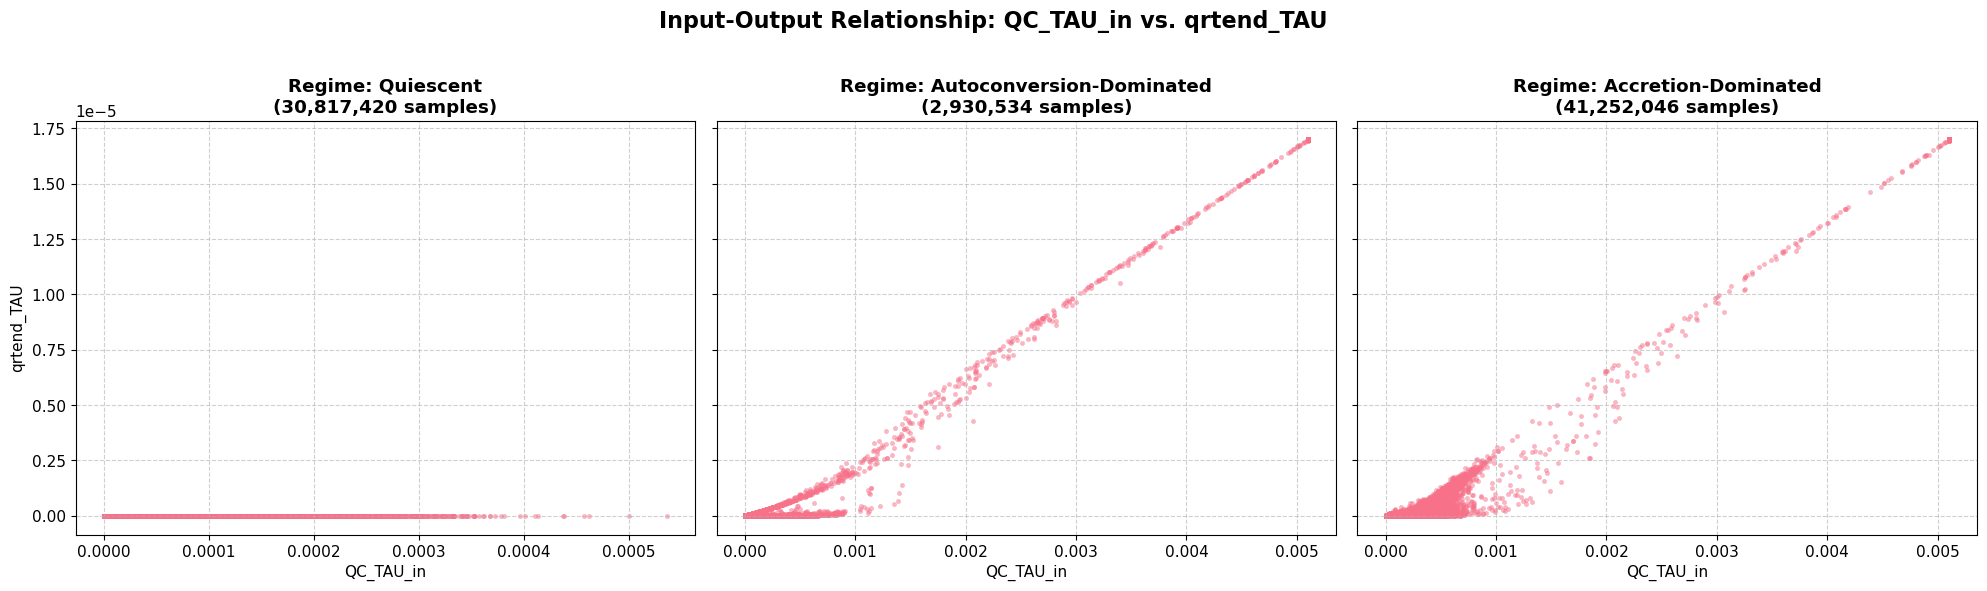


Generating comparison plot for: N0R vs. nrtend_TAU


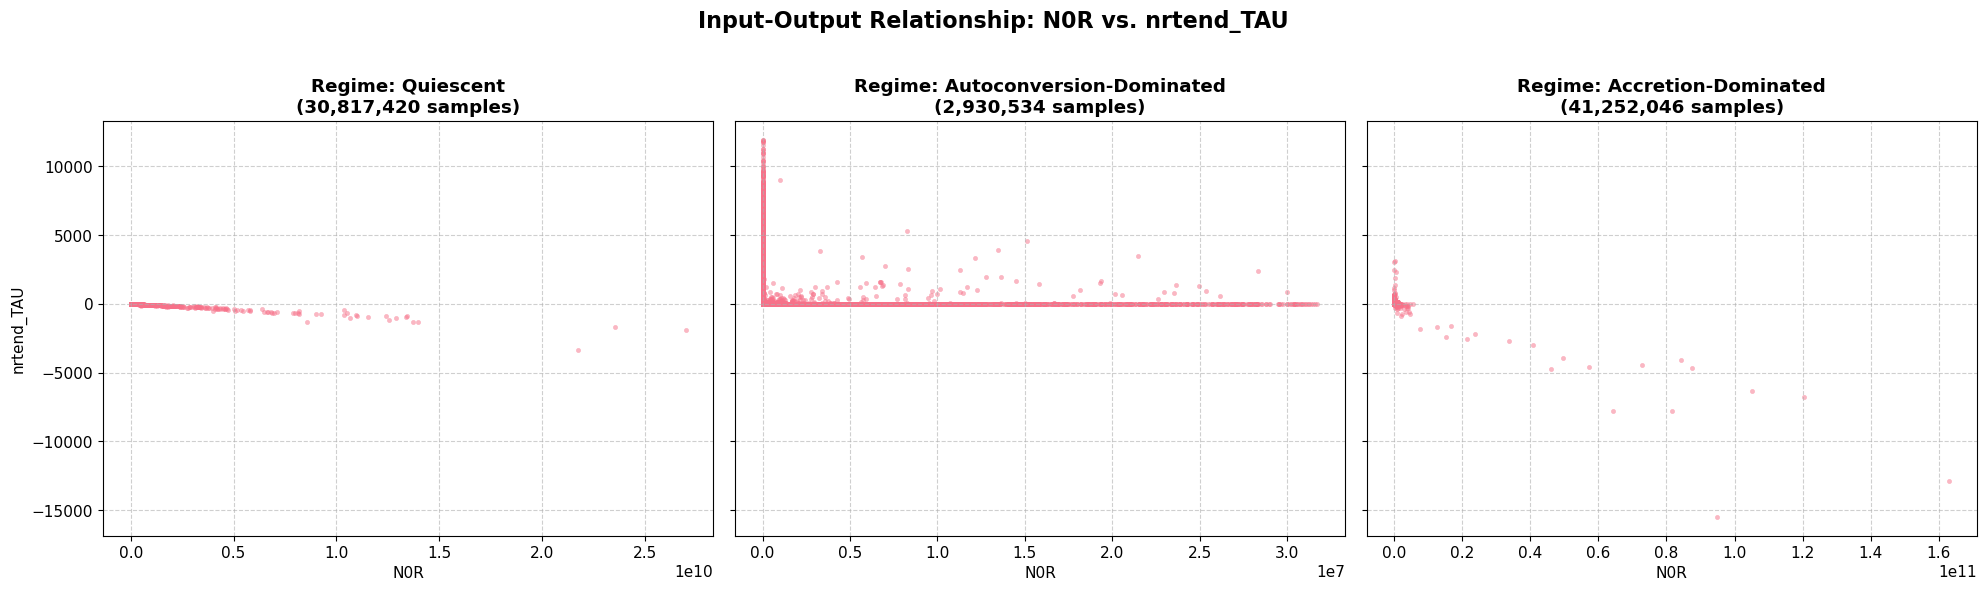


Generating comparison plot for: NC_TAU_in vs. nctend_TAU


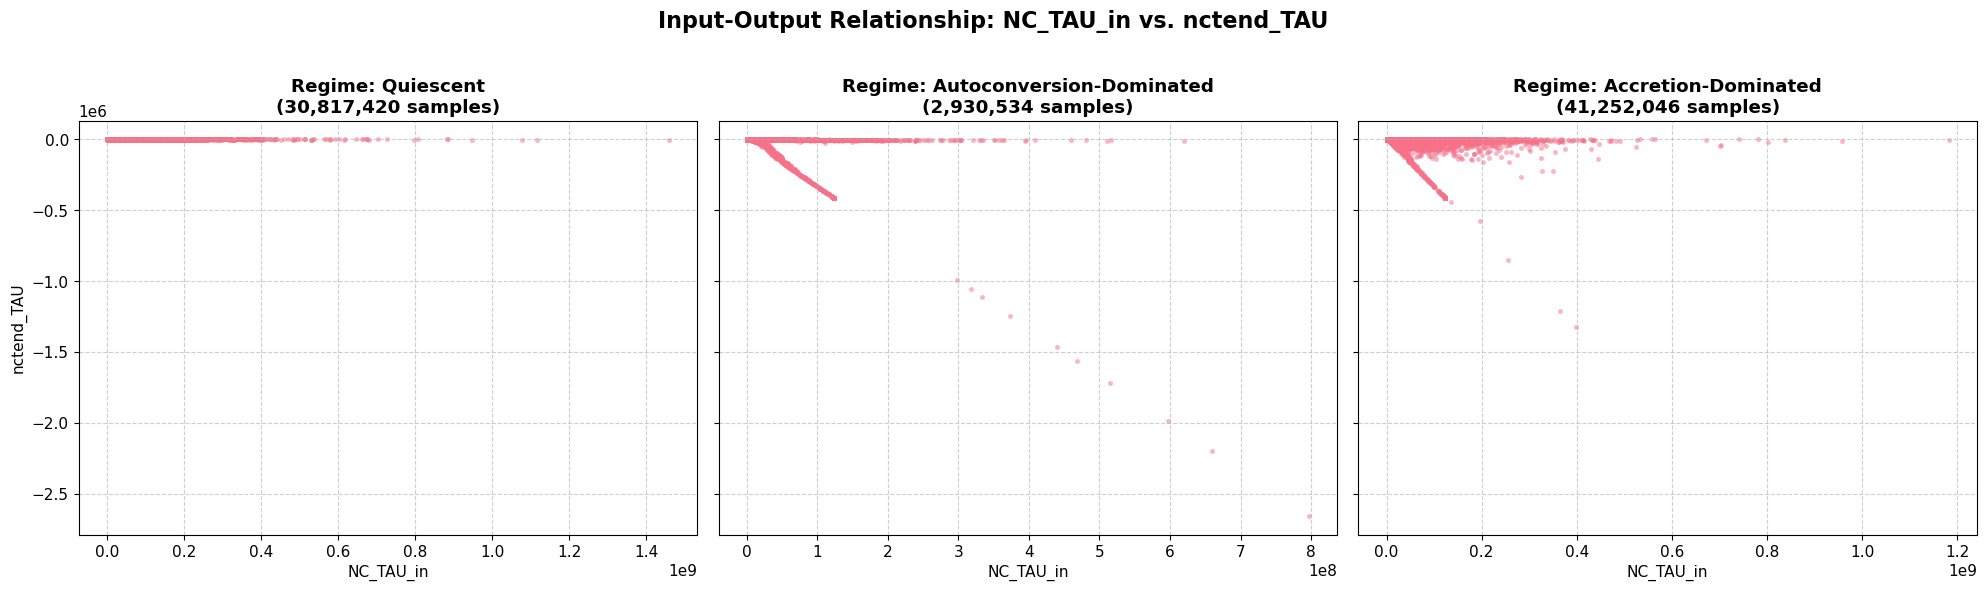


Generating comparison plot for: NR_TAU_in vs. nrtend_TAU


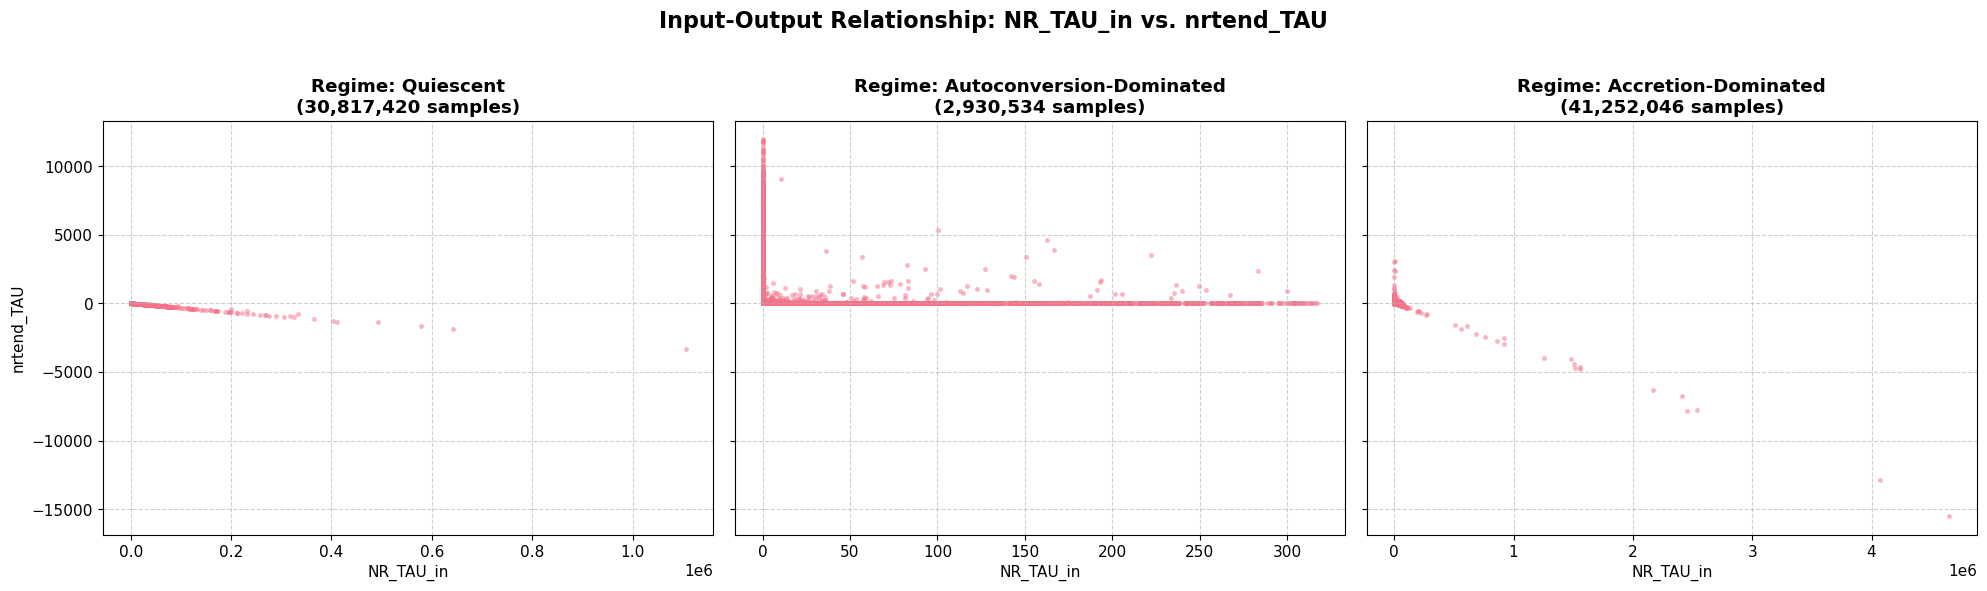


Generating comparison plot for: NC_TAU_in vs. nctend_TAU


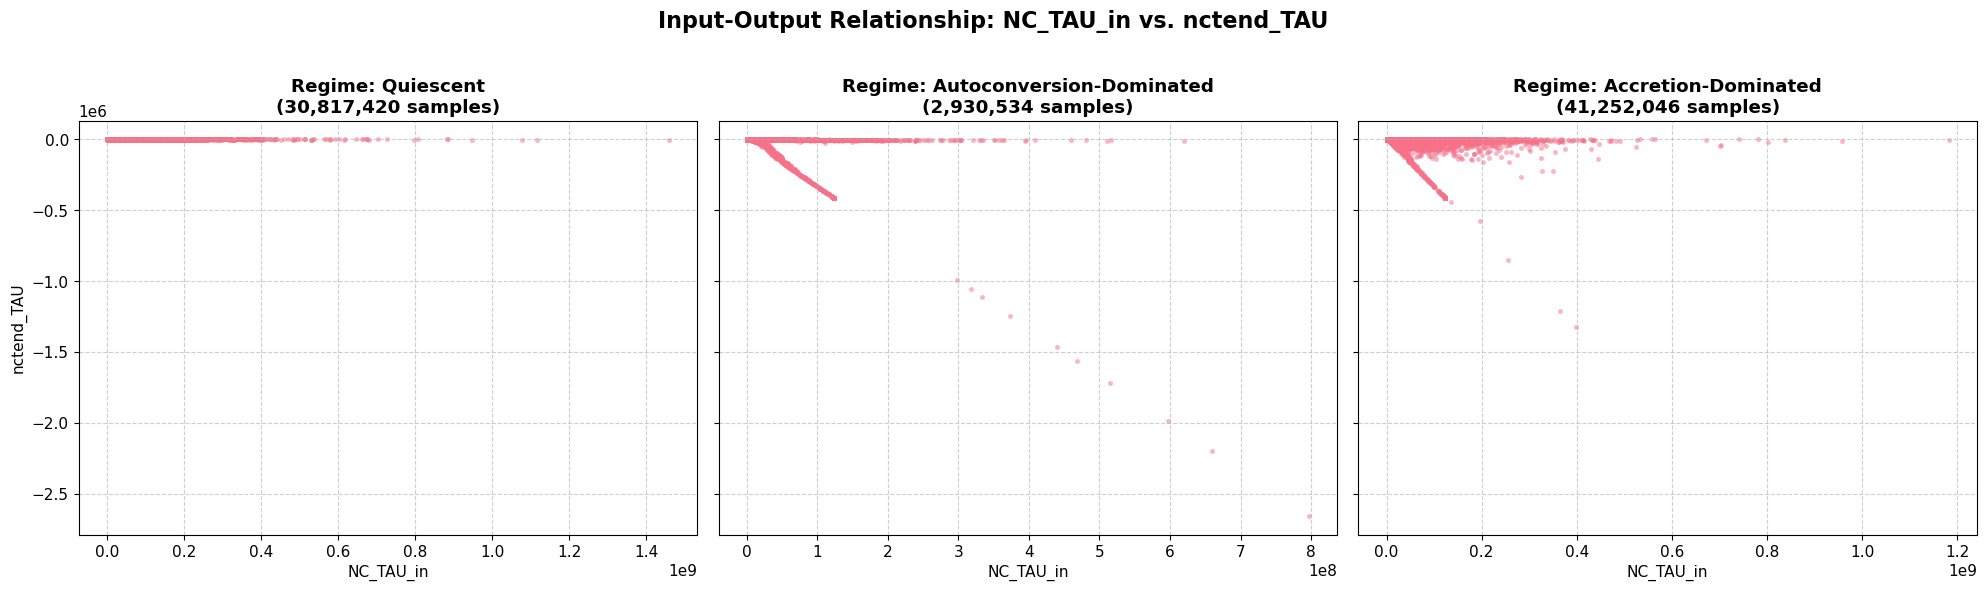


Generating comparison plot for: QC_TAU_in vs. nctend_TAU


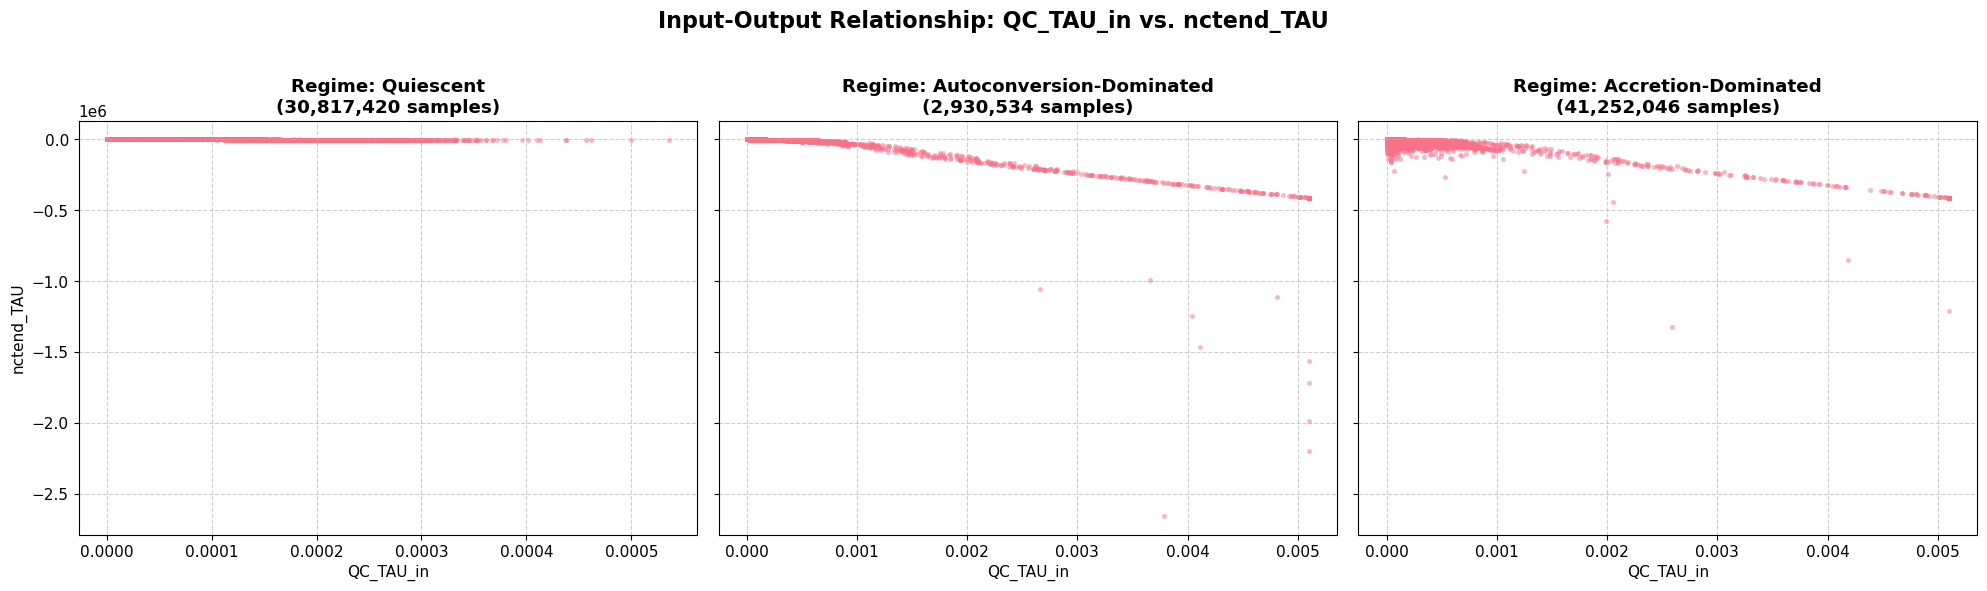


Generating comparison plot for: PGAM vs. nctend_TAU


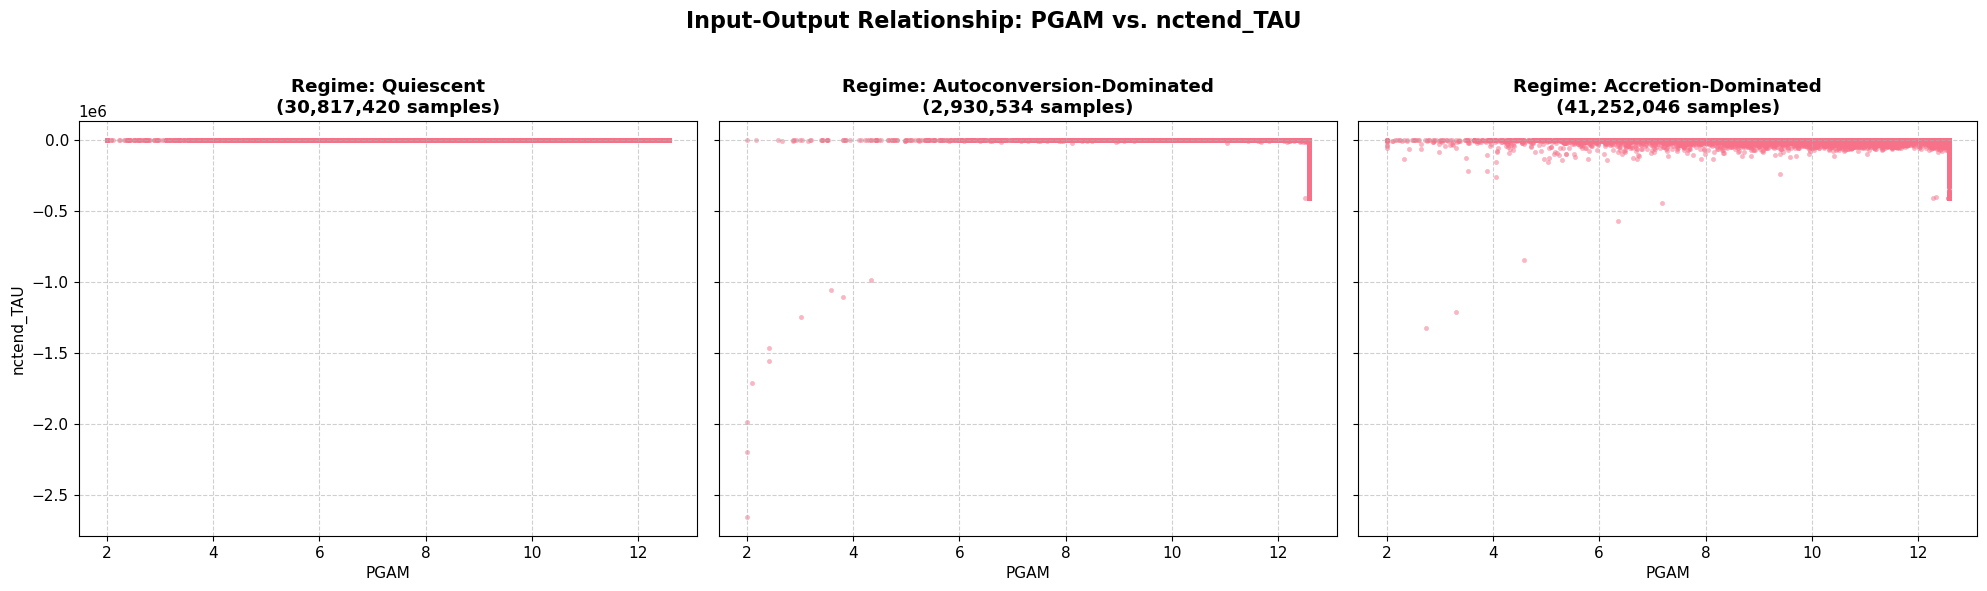


✅ Faceted scatter plot analysis complete!


In [21]:
print("🔬 Task 3.1b: Generating Scatter Plots Faceted by Process Regime")
print("=" * 70)

# 1. Define the key input-output pairs we want to investigate
# -----------------------------------------------------------
# These are the most direct physical relationships for mass and number.
plots_to_create = [
    ('QC_TAU_in', 'qrtend_TAU'),   # Cloud Mass -> Rain Tendency
    ('N0R', 'nrtend_TAU'),         # Intercept -> Rain Number Tendency
    ('NC_TAU_in', 'nctend_TAU'),   # Cloud Number -> Cloud Number Tendency
    ('NR_TAU_in', 'nrtend_TAU'),   # Rain Number -> Rain Number Tendency
    ('NC_TAU_in', 'nctend_TAU'),   # Cloud Number Tendency -> Cloud Number Tendency
    ('QC_TAU_in', 'nctend_TAU'),   # Cloud Mass -> Cloud Number Tendency
    ('PGAM', 'nctend_TAU')         # Shape parameter for the drop size distribution -> Cloud Number Tendency
]


# Set a consistent sample size for plotting to keep visuals clean
SAMPLES_FOR_PLOT = 20000

# 2. Loop through each plot definition and create a comparison figure
# --------------------------------------------------------------------
for input_var, output_var in plots_to_create:    
    print(f"\nGenerating comparison plot for: {input_var} vs. {output_var}")
    
    # Create a figure with 3 subplots, one for each regime
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    fig.suptitle(f'Input-Output Relationship: {input_var} vs. {output_var}', fontsize=16, fontweight='bold')

    # Loop through our defined regimes
    for i, (regime_name, mask) in enumerate(process_regimes.items()):
        
        ax = axes[i]
        regime_df = combined_representative[mask]
        
        # Check if there's data for the regime
        if len(regime_df) > 0:
            # Sample the data for efficient plotting
            if len(regime_df) > SAMPLES_FOR_PLOT:
                plot_data = regime_df.sample(SAMPLES_FOR_PLOT, random_state=42)
            else:
                plot_data = regime_df

            # Create the scatter plot
            sns.scatterplot(x=input_var, y=output_var, data=plot_data, s=10, alpha=0.5, ax=ax, edgecolor=None)
        
        ax.set_title(f'Regime: {regime_name}\n({len(regime_df):,} samples)', fontweight='bold')
        ax.set_xlabel(input_var)
        ax.grid(True, linestyle='--', alpha=0.6)

    # Common adjustments for all subplots
    axes[0].set_ylabel(output_var)
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
    #plt.savefig("regime_specific_scatter_plots")
    plt.show()

print("\n✅ Faceted scatter plot analysis complete!")

## 💧 3.3 Regime-specific Mean Droplet Size Disrtibution (Please ignore this for now)


Generating comparison histograms for Mean Droplet Size...


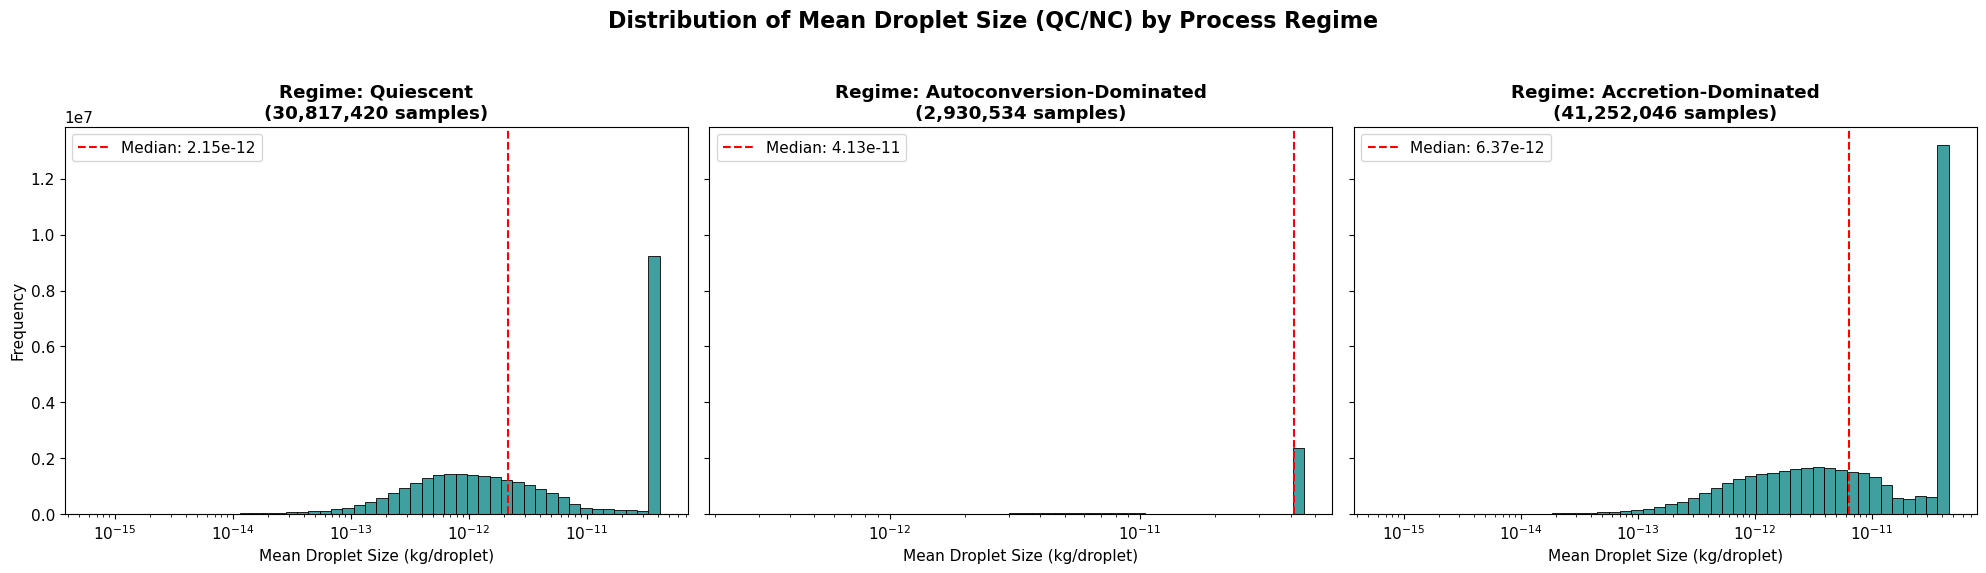


✅ Mean droplet size analysis complete!


In [22]:
# 1. Calculate the mean droplet size (our derived physical feature)
# -------------------------------------------------------------------
# Create a mask to avoid division by zero where cloud number is zero
valid_mask = combined_representative['NC_TAU_in'] > 1e-10
# Create a new column in the DataFrame for this derived feature
combined_representative['mean_droplet_size'] = np.nan # Initialize with NaNs
combined_representative.loc[valid_mask, 'mean_droplet_size'] = \
    combined_representative.loc[valid_mask, 'QC_TAU_in'] / combined_representative.loc[valid_mask, 'NC_TAU_in']


# 2. Create and display the comparison histograms
# -------------------------------------------------
print("\nGenerating comparison histograms for Mean Droplet Size...")

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Distribution of Mean Droplet Size (QC/NC) by Process Regime', fontsize=16, fontweight='bold')

for i, (regime_name, mask) in enumerate(process_regimes.items()):
    ax = axes[i]
    
    # Select the mean droplet size data for the current regime, dropping any NaNs
    plot_data = combined_representative.loc[mask, 'mean_droplet_size'].dropna()
    
    if not plot_data.empty:
        # Use seaborn's histplot with a log scale for the x-axis to see the distribution clearly
        sns.histplot(plot_data, ax=ax, log_scale=True, bins=50, color='teal')
        
        # Add a vertical line for the median value of the regime
        median_val = plot_data.median()
        ax.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.2e}')
        ax.legend()

    ax.set_title(f'Regime: {regime_name}\n({mask.sum():,} samples)', fontweight='bold')
    ax.set_xlabel('Mean Droplet Size (kg/droplet)')

axes[0].set_ylabel('Frequency')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n✅ Mean droplet size analysis complete!")

## 🧠  Phase 3 Insights and Guidance for Architecture Design

- 🏗️ Multi-head architecture is the preferred choice.
- 🎎 Storng need of log-transformation and possible layer normalization in each layer.
- 💧 Mean droplet size could be an important "made-up" feature for efficient learning

# 🏗️ ML Emulator Design Blueprint



The proposed architecture and training strategy for the warm rain process emulator, based on insights from our comprehensive Exploratory Data Analysis (EDA).

#### 🏛️ Proposed Architecture: 
Single-Body, Multi-Task NetworkOur design focuses on creating a single, efficient model that handles the problem's multiple facets, improving upon the multi-model approach from previous work.             
                         

  +----------------------------+
                           |   Input Variables (14+)    |
                           | (log-transformed & scaled) |
                           +----------------------------+
                                        |
                                        v
                          +------------------------------+
                          |      Shared "Body"           |
                          | (e.g., 3-4 Dense Layers      |
                          |  with ReLU/LeakyReLU)        |
                          +------------------------------+
                                        |
              +-------------------------+-------------------------+
              |                                                   |
              v                                                   v
+-----------------------------+               +-------------------------------------+
| Head 1: Is_Active           |               |       Regression Heads              |
| (Classifier)                |               |   (for Active Samples Only)         |
| [1 neuron, Sigmoid output]  |               +-------------------------------------+
+-----------------------------+                         |           |           |
                                                        v           v           v
                                                 +----------+ +----------+ +----------+
                                                 | qrtend   | | nctend   | | nrtend   |
                                                 | (ReLU)   | | (-ReLU)  | | (Linear) |
                                                 +----------+ +----------+ +----------+



#### 📝 Key Design & Training Recommendations:

Here are the specific, data-driven guidelines for building our *"physics-informed emulator"*:
- ✨ **Data Preprocessing**
    - 🪵 Logarithmic Transformation: This is mandatory for all highly skewed microphysical variables (both inputs and outputs). Our EDA showed this is essential to handle the vast dynamic range and reveal the underlying data structure. Use log(x + ε) to manage zero values.
    - ⚖️ Standardization: After the log transform, all input features must be standardized (e.g., using StandardScaler). This centers the data around a mean of 0 and a standard deviation of 1, which is critical for stable and efficient neural network training.
- 🧠 **Model Architecture & Physical Constraints**:
  
  🤝*Multi-Task Design*: We will use a single network with a shared "body" to learn common features and multiple "heads" for specialized tasks. This is simpler and more efficient than training separate models.
- 📉 **Mass Conservation by Design**:

  Our analysis confirmed that qctend_TAU is the perfect negative of qrtend_TAU. Therefore, the model will only predict qrtend_TAU. We will derive qctend_TAU in a post-prediction step (qctend_TAU = -qrtend_TAU). This hard-codes a fundamental physical law into our model, reducing error and complexity.
- 🚪 **Activation Functions as Physical Constraints**:

    We will enforce physical constraints directly on the output neurons of the regression heads to **prevent unphysical predictions**:
    - qrtend_TAU Head: Must predict a value ≥0. Use a ReLU or Softplus activation.
    - nctend_TAU Head: Must predict a value ≤0. Have the head output a positive value using a ReLU activation, then multiply the result by -1.
    - nrtend_TAU Head: Probably the most complex head to model (based on scatter plots). Can be positive (autoconversion) or negative (accretion). This head must use a Linear activation (no activation function) to allow it the freedom to predict values across the full range.
- 🎯 **Loss Function & Training Strategy**:

  - **A Combined Loss Function**: The model will be trained on a combined loss:
    - Classification Loss: A Binary Cross-Entropy loss will be calculated for the is_active_classifier head on all samples in a batch. This teaches the model to distinguish *"active"* from *"quiescent"* states.
    - Regression Loss: A robust loss function like Huber Loss or Mean Absolute Error (MAE) will be used for the three regression heads. Crucially, this loss will be calculated only on the samples where the is_active target is true, using a differentiable masking technique during the loss calculation.
  - **⚖️ Loss Weighting**: We can introduce a hyperparameter (alpha) to balance the importance of the classification and regression losses (e.g., total_loss = alpha * classification_loss + (1 - alpha) * regression_loss).This blueprint provides a clear, well-justified path forward. It directly addresses the complexities we discovered in the data and aims to create a simpler, yet more physically sound, emulator than what has been done before.

In [23]:
# Import lightgbm library if not already installed
#%pip install lightgbm

In [24]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


🎯 Starting Feature Importance Analysis with a 'Scout' Model
Step 1: Subsampling data to 500,000 rows for efficiency...
Step 2: Preprocessing data (log-transforming skewed inputs and outputs)...
Preprocessing complete.
------------------------------------------------------------
Step 3 & 4: Training scout models with early stopping and plotting feature importance...

--- Analyzing Target: qctend_TAU (transformed) ---
Training LightGBM model with early stopping...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048821 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3095
[LightGBM] [Info] Number of data points in the train set: 320000, number of used features: 13
[LightGBM] [Info] Start training from score -0.000001
Training complete.
✅ Final Validation RMSE: 0.0000
   (Model trained for 164 boosting rounds)


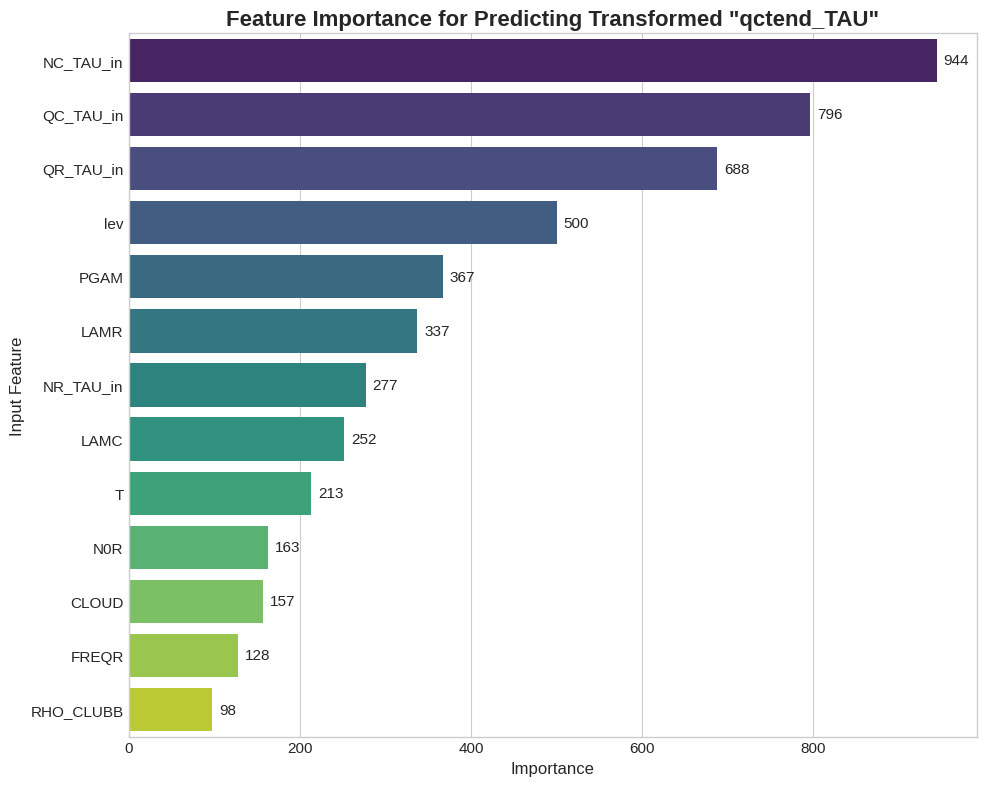

Top 5 most important features for qctend_TAU:
      feature  importance
5   NC_TAU_in         944
4   QC_TAU_in         796
6   QR_TAU_in         688
12        lev         500
8        PGAM         367
--------------------------------------------------

--- Analyzing Target: nctend_TAU (transformed) ---
Training LightGBM model with early stopping...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3095
[LightGBM] [Info] Number of data points in the train set: 320000, number of used features: 13
[LightGBM] [Info] Start training from score -5.110860
Training complete.
✅ Final Validation RMSE: 0.0955
   (Model trained for 1000 boosting rounds)


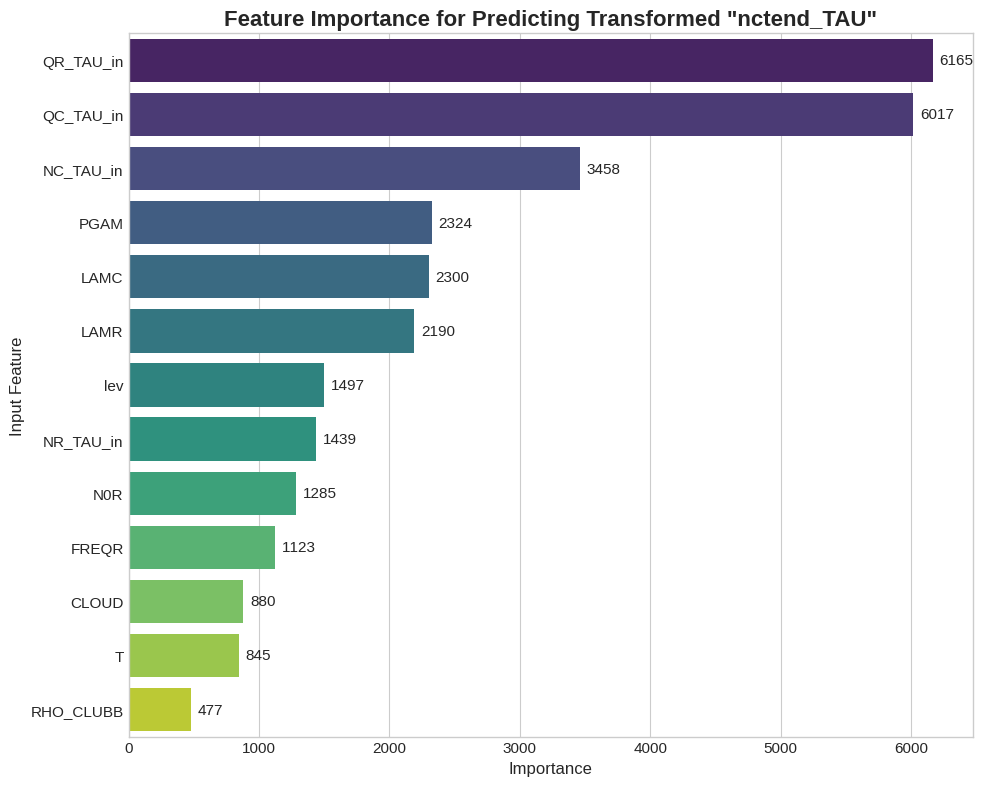

Top 5 most important features for nctend_TAU:
     feature  importance
6  QR_TAU_in        6165
4  QC_TAU_in        6017
5  NC_TAU_in        3458
8       PGAM        2324
9       LAMC        2300
--------------------------------------------------

--- Analyzing Target: qrtend_TAU (transformed) ---
Training LightGBM model with early stopping...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054838 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3095
[LightGBM] [Info] Number of data points in the train set: 320000, number of used features: 13
[LightGBM] [Info] Start training from score 0.000001
Training complete.
✅ Final Validation RMSE: 0.0000
   (Model trained for 164 boosting rounds)


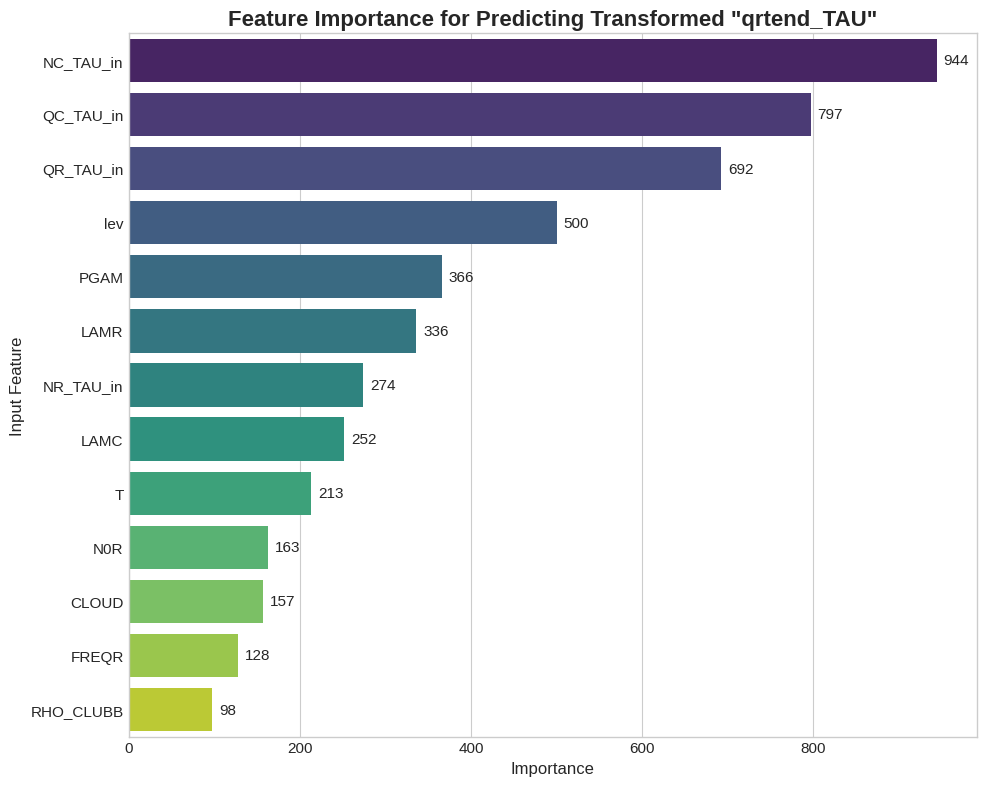

Top 5 most important features for qrtend_TAU:
      feature  importance
5   NC_TAU_in         944
4   QC_TAU_in         797
6   QR_TAU_in         692
12        lev         500
8        PGAM         366
--------------------------------------------------

--- Analyzing Target: nrtend_TAU (transformed) ---
Training LightGBM model with early stopping...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3095
[LightGBM] [Info] Number of data points in the train set: 320000, number of used features: 13
[LightGBM] [Info] Start training from score 0.211298
Training complete.
✅ Final Validation RMSE: 0.2196
   (Model trained for 999 boosting rounds)


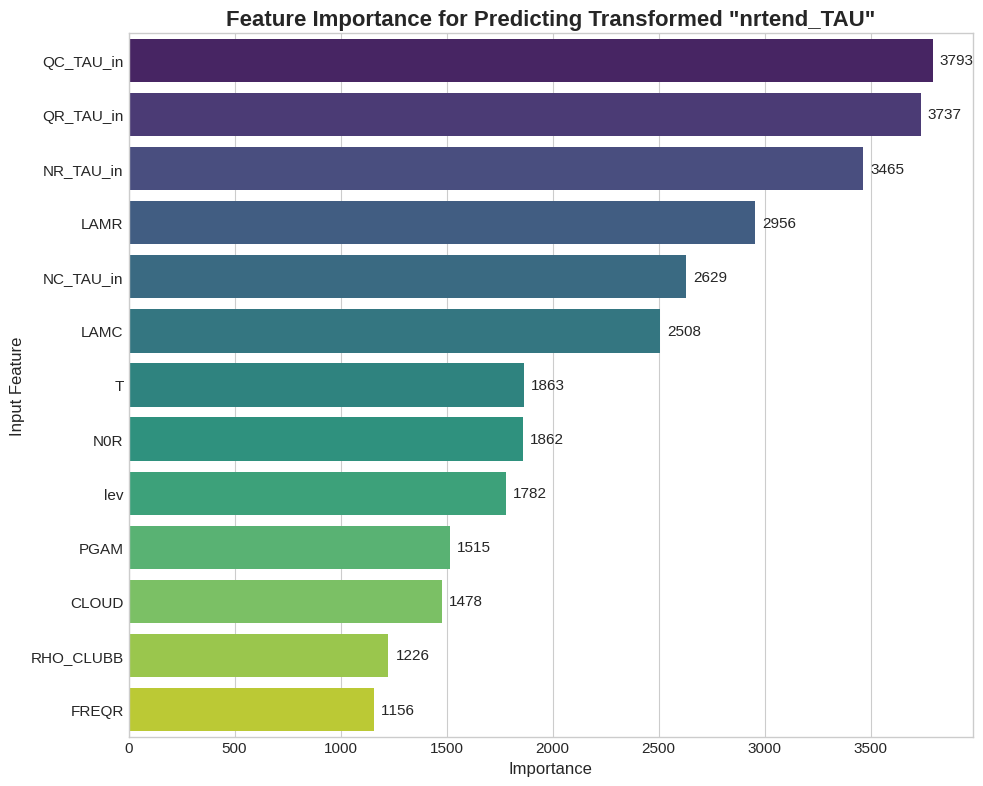

Top 5 most important features for nrtend_TAU:
      feature  importance
4   QC_TAU_in        3793
6   QR_TAU_in        3737
7   NR_TAU_in        3465
10       LAMR        2956
5   NC_TAU_in        2629
--------------------------------------------------

✅ Scout model analysis complete!


In [27]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


print("🎯 Starting Feature Importance Analysis with a 'Scout' Model")
print("=" * 60)


# --- Step 1: Subsample Data for Speed ---
SAMPLE_SIZE = min(500000, len(combined_representative))
print(f"Step 1: Subsampling data to {SAMPLE_SIZE:,} rows for efficiency...")
df_scout = combined_representative.sample(n=SAMPLE_SIZE, random_state=42)


# --- Step 2: Preprocessing ---
print("Step 2: Preprocessing data (log-transforming skewed inputs and outputs)...")

input_vars = [
    'T', 'RHO_CLUBB', 'CLOUD', 'FREQR',
    'QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in',
    'PGAM', 'LAMC', 'LAMR', 'N0R', 'lev'
]
input_vars = [var for var in input_vars if var in df_scout.columns]

output_vars = ['qctend_TAU', 'nctend_TAU', 'qrtend_TAU', 'nrtend_TAU']

# Preprocess Inputs
log_transform_inputs = [
    'QC_TAU_in', 'NC_TAU_in', 'QR_TAU_in', 'NR_TAU_in',
    'LAMC', 'LAMR', 'N0R'
]
X = df_scout[input_vars].copy()
epsilon = 1e-15
for var in log_transform_inputs:
    if var in X.columns:
        X[var] = np.log(X[var] + epsilon)

# Preprocess Outputs (Targets)
y = df_scout[output_vars].copy()
for var in output_vars:
    y[var] = np.sign(y[var]) * np.log1p(np.abs(y[var]))

print("Preprocessing complete.")
print("-" * 60)


# --- Step 3 & 4: Loop, Train Scout Model with Early Stopping, and Plot Importance ---
print("Step 3 & 4: Training scout models with early stopping and plotting feature importance...\n")

all_feature_importances = {}

for target_var in output_vars:
    print(f"--- Analyzing Target: {target_var} (transformed) ---")

    y_target = y[target_var]
    
    # Split data into training and a final test set
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)
    # Further split the training data to create a validation set for early stopping
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

    print("Training LightGBM model with early stopping...")
    # Increase n_estimators and let early stopping find the optimal number of rounds
    lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1, n_estimators=1000)
    
    lgbm.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             eval_metric='rmse', # Root Mean Squared Error
             callbacks=[lgb.early_stopping(10, verbose=False)]) # Stop if validation RMSE doesn't improve for 10 rounds

    print("Training complete.")

    # --- Evaluate Model Performance ---
    y_pred = lgbm.predict(X_test)
    final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"✅ Final Validation RMSE: {final_rmse:.4f}")
    print(f"   (Model trained for {lgbm.best_iteration_} boosting rounds)")

    # Get and store feature importances
    importances = lgbm.feature_importances_
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    all_feature_importances[target_var] = importance_df

    # --- Visualization ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis', ax=ax)
    
    ax.set_title(f'Feature Importance for Predicting Transformed "{target_var}"', fontsize=16, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_ylabel('Input Feature', fontsize=12)
    
    for p in ax.patches:
        ax.annotate(f"{int(p.get_width())}", 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha = 'left', va = 'center', 
                    xytext = (5, 0), 
                    textcoords = 'offset points')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Top 5 most important features for {target_var}:")
    print(importance_df.head(5))
    print("-" * 50 + "\n")

print("✅ Scout model analysis complete!")